# Project Setup

## Import Python Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.neighbors import NearestNeighbors
import umap

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Cluster label matching
from scipy.optimize import linear_sum_assignment

# Deep learning / VAE
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Utilities
import random
import warnings

warnings.filterwarnings("ignore")

print("Python libraries imported successfully")

Python libraries imported successfully


**Observation :**

Imports libraries required for data handling, visualization, dimensionality reduction, clustering, cluster comparison, VAE modelling and utility functions.

The environment contains the required dependencies to execute the embedding and clustering pipeline.

## Setting Random Seed and Plotting Settings

In [2]:
# Set a fixed random seed for reproducible results
RANDOM_SEED = 1606

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Set seed for GPU if available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Set plotting style
sns.set_theme(style="whitegrid", context="notebook")

# Set default figure properties
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print(f"Random Seed Set to: {RANDOM_SEED}")
print("Plotting Settings Configured Successfully")

Random Seed Set to: 1606
Plotting Settings Configured Successfully


**Observation :**

Sets a fixed random seed (`1606`) for Python, NumPy and PyTorch to make stochastic results reproducible and configures consistent Seaborn/Matplotlib plot settings.

Using the same seed helps reproduce the same randomized results across repeated runs while fixed plotting settings keep all figures visually consistent.

## Defining Project Folder Paths

In [3]:
# Current notebook folder
NOTEBOOK_DIR = Path.cwd()

# Project root folder
ROOT_FOLDER = NOTEBOOK_DIR.parent

# Main project folders
DATA_DIR = ROOT_FOLDER / "results" / "1.dataset_creation"
RESULTS_DIR = ROOT_FOLDER / "results" / "2.embedding_clustering"
PLOTS_DIR = ROOT_FOLDER / "plots" / "2.embedding_clustering"

# Create output folders if they do not exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Display paths
print(f"Project Root: {ROOT_FOLDER}")
print(f"Data Folder: {DATA_DIR}")
print(f"Results Folder: {RESULTS_DIR}")
print(f"Plots Folder: {PLOTS_DIR}")

Project Root: C:\Users\samsa\Documents\ICU Clustering
Data Folder: C:\Users\samsa\Documents\ICU Clustering\results\1.dataset_creation
Results Folder: C:\Users\samsa\Documents\ICU Clustering\results\2.embedding_clustering
Plots Folder: C:\Users\samsa\Documents\ICU Clustering\plots\2.embedding_clustering


**Observation :**

Defines the project root, input data folder, results folder and plots folder using `Path` and creates the output directories if they do not already exist.

The project uses a structured directory setup, keeping input data, results and visualizations organized separately.

Using `Path` makes file handling cleaner and more reliable while automatically creating output folders prevents file-saving errors later in the notebook.

# Load and Prepare the Data

## Load the Scaled Dataset and Feature Names

In [4]:
# Load the scaled clustering dataset
scaled_df = pd.read_csv(DATA_DIR / "clustering_dataset_scaled.csv")

# Load the feature names
feature_names_df = pd.read_csv(DATA_DIR / "clustering_feature_names.csv")

# Display dataset dimensions
print(f"Scaled Dataset Shape: {scaled_df.shape}")
print(f"Feature Names Shape: {feature_names_df.shape}")

Scaled Dataset Shape: (7859, 81)
Feature Names Shape: (80, 1)


**Observation :**  

Loads the scaled clustering dataset and the list of selected clustering feature names from CSV files.

The scaled dataset has `7859` patients and `81` columns while the feature-name file contains `80` clustering features.

The dataset contains `80` clustering features + one identifier column `patientunitstayid`.

## Inspecting the Dataset and Feature Names

In [5]:
# Display column names in the scaled dataset
print("Scaled Dataset Columns:")
print(scaled_df.columns.to_list())

# Display clustering feature names
print("\nClustering Feature Names:")
print(feature_names_df.iloc[:, 0].to_list())

Scaled Dataset Columns:
['patientunitstayid', 'age', 'gender', 'admissionheight', 'admissionweight', 'BUN_min', 'Hgb_min', 'WBC x 1000_min', 'anion gap_min', 'bicarbonate_min', 'chloride_min', 'creatinine_min', 'glucose_min', 'lactate_min', 'platelets x 1000_min', 'potassium_min', 'sodium_min', 'BUN_max', 'Hgb_max', 'WBC x 1000_max', 'anion gap_max', 'bicarbonate_max', 'chloride_max', 'creatinine_max', 'glucose_max', 'lactate_max', 'platelets x 1000_max', 'potassium_max', 'sodium_max', 'BUN_mean', 'Hgb_mean', 'WBC x 1000_mean', 'anion gap_mean', 'bicarbonate_mean', 'chloride_mean', 'creatinine_mean', 'glucose_mean', 'lactate_mean', 'platelets x 1000_mean', 'potassium_mean', 'sodium_mean', 'BUN_std', 'Hgb_std', 'WBC x 1000_std', 'anion gap_std', 'bicarbonate_std', 'chloride_std', 'creatinine_std', 'glucose_std', 'lactate_std', 'platelets x 1000_std', 'potassium_std', 'sodium_std', 'lab_measurement_count', 'sao2_fpc_1', 'sao2_fpc_2', 'sao2_fpc_3', 'sao2_fpc_4', 'sao2_fpc_5', 'sao2_fpc_6'

**Observation :**  

Displays all columns in the scaled dataset and compares them with the selected clustering feature list.

The dataset contains `81` columns : `80` clustering features and `1` identifier column `patientunitstayid`.

The feature list correctly matches the clustering variables and excludes the patient ID from analysis.

This verification ensures that only intended clinical features are used for dimensionality reduction and clustering, preventing the identifier column from influencing the results.

## Preparing the Feature Matrix

In [6]:
# Convert feature names into a Python list
feature_names = feature_names_df.iloc[:, 0].tolist()

# Store patient IDs separately
patient_ids = scaled_df["patientunitstayid"].copy()

# Create the feature matrix using only clustering features
X = scaled_df[feature_names].copy()

# Display dimensions
print(f"Number of Patients: {X.shape[0]}")
print(f"Number of Features: {X.shape[1]}")
print(f"Patient IDs Stored: {len(patient_ids)}")

Number of Patients: 7859
Number of Features: 80
Patient IDs Stored: 7859


**Observation :**  

Converts the feature names into a list stores `patientunitstayid` separately and creates the clustering feature matrix `X` using only the `80` selected features.

The feature matrix contains `7859` patients and `80` clustering features with `7859` patient IDs stored separately.

The dataset is correctly separated into identifiers and numerical features required for dimensionality reduction and clustering.

Patient IDs must be excluded because they do not contain clinical information and should not influence distances, embeddings, or cluster formation.

## Checking for Missing and Infinite Values

In [7]:
# Count missing values
missing_values = X.isna().sum().sum()

# Count infinite values
infinite_values = np.isinf(X.to_numpy()).sum()

# Display results
print(f"Total Missing Values: {missing_values}")
print(f"Total Infinite Values: {infinite_values}")

Total Missing Values: 0
Total Infinite Values: 0


**Observation :**  

Checks the feature matrix `X` for missing (`NaN`) and infinite (`Inf`) values.

The output shows `0` missing values and `0` infinite values.

The feature matrix is clean and contains only valid numerical values.

Missing or infinite values can cause dimensionality-reduction and clustering algorithms to fail or produce unreliable results.

# Dimensionality Reduction

## Create the PCA Embedding

In [8]:
# Apply PCA while retaining 95% of the variance
pca = PCA(
    n_components=0.95,
    svd_solver="full"
)

# Fit PCA and transform the feature matrix
pca_embedding = pca.fit_transform(X)

# Reconstruct the original data
X_reconstructed = pca.inverse_transform(pca_embedding)

# Calculate reconstruction error
reconstruction_error = np.mean(
    (X.to_numpy() - X_reconstructed) ** 2
)

# Store explained variance
pca_variance_df = pd.DataFrame({
    "Component": [f"PC{i + 1}" for i in range(pca.n_components_)],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative_Explained_Variance": np.cumsum(
        pca.explained_variance_ratio_
    )
})

# Store first two components for visualization
pca_df = pd.DataFrame({
    "patientunitstayid": patient_ids,
    "pca_1": pca_embedding[:, 0],
    "pca_2": pca_embedding[:, 1]
})

# # Save results
pca_variance_df.to_csv(
    RESULTS_DIR / "01.pca_explained_variance.csv",
    index=False
)

pca_df.to_csv(
    RESULTS_DIR / "02.pca_embedding.csv",
    index=False
)

# Display PCA summary
print(f"Original Number of Features: {X.shape[1]}")
print(f"PCA Components Retained: {pca.n_components_}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Reconstruction Error: {reconstruction_error:.4f}")

Original Number of Features: 80
PCA Components Retained: 25
Total Explained Variance: 0.9545
Reconstruction Error: 0.0009


**Observation :**  

Applies PCA to the 80-feature dataset and automatically retains enough components to explain at least `95%` of the total variance. It also reconstructs the data to measure information loss.

PCA reduced `80` original features to `25` components while preserving `95.45%` of the total variance. The reconstruction error is very low at `0.0009`.

Most of the important variation in the 80-dimensional dataset can be represented using only `25` principal components with minimal information loss.

PCA reduces dimensionality, redundancy, and correlated information while preserving most of the dataset's variance, providing a compact linear representation for further clustering analysis.

## Plotting the PCA Embedding using the First Two Components

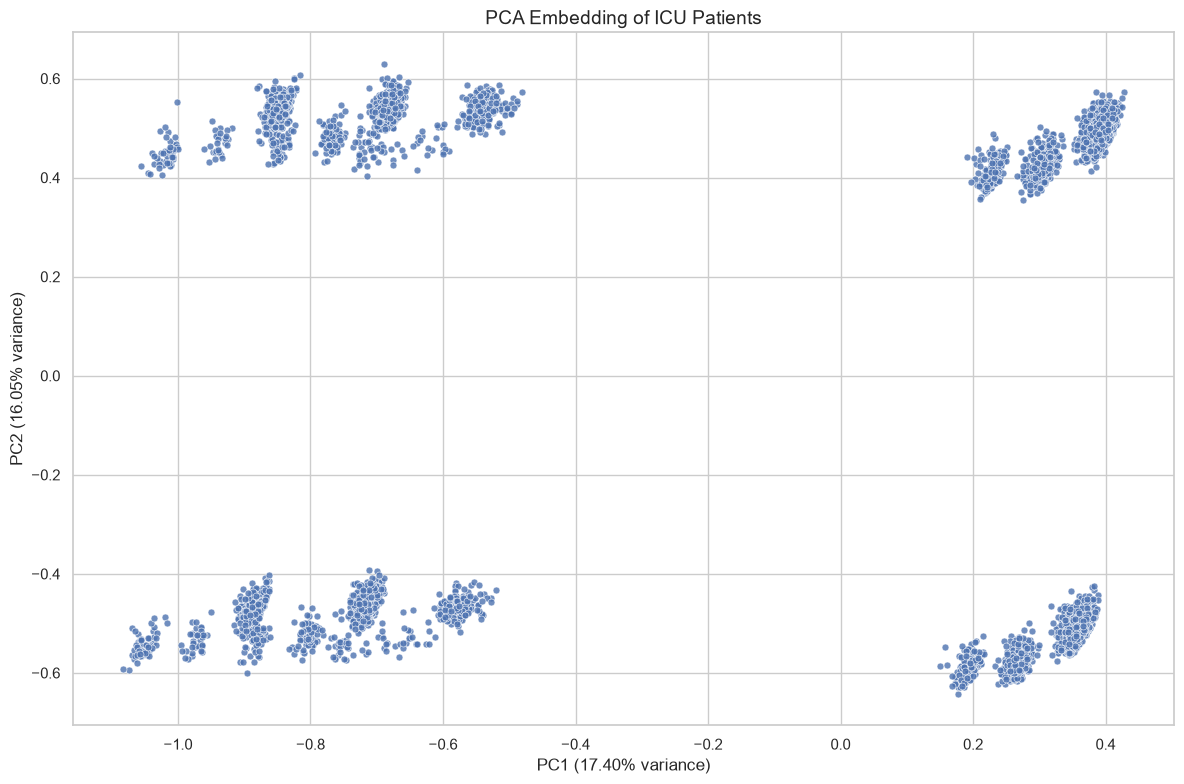

In [9]:
# Create a 2D PCA scatter plot using the first two components
plt.figure(figsize=(12, 8))

plt.scatter(
    pca_embedding[:, 0],
    pca_embedding[:, 1],
    s=25,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.8
)

# Label axes with explained variance
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")

plt.title("PCA Embedding of ICU Patients")
plt.tight_layout()

# Save plot
plt.savefig(
    PLOTS_DIR / "01.pca_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation :**  

Plots the first two principal components, `PC1` and `PC2`, to visualize the patient distribution in a 2D PCA space.

The plot shows several separated patient groups. `PC1` and `PC2` together explain `33.45%` of the total variance.

The first two components reveal visible structure in the dataset, including approximately four major groups with smaller subgroups. However, the plot represents only part of the total information captured by PCA.

The first two principal components are used because they capture the maximum possible variance in two dimensions, making the high-dimensional dataset easier to visualize.

## Create T-SNE Embedding

### Perplexity Search and Trustworthiness Evaluation

In [10]:
# Candidate perplexity values
perplexity_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Store embeddings and evaluation results
tsne_embeddings = {}
tsne_tuning_results = []

# Run t-SNE for each perplexity
for perplexity in perplexity_values:

    # Create t-SNE model
    tsne_model = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=RANDOM_SEED
    )

    # Apply t-SNE directly to the 80-feature matrix
    embedding = tsne_model.fit_transform(X)

    # Store embedding
    tsne_embeddings[perplexity] = embedding

    # Calculate trustworthiness
    trust_score = trustworthiness(
        X,
        embedding,
        n_neighbors=30
    )

    # Calculate continuity
    continuity_score = trustworthiness(
        embedding,
        X,
        n_neighbors=30
    )

    # Overall embedding quality
    quality_score = (
        trust_score + continuity_score
    ) / 2

    # Store results
    tsne_tuning_results.append({
        "Perplexity": perplexity,
        "Trustworthiness": trust_score,
        "Continuity": continuity_score,
        "Quality_Score": quality_score
    })

    print(
        f"Perplexity: {perplexity} | "
        f"Trustworthiness: {trust_score:.4f} | "
        f"Continuity: {continuity_score:.4f} | "
        f"Quality: {quality_score:.4f}"
    )

# Convert results to DataFrame
tsne_tuning_df = pd.DataFrame(tsne_tuning_results)

# Sort from best to worst
tsne_tuning_df = tsne_tuning_df.sort_values(
    "Quality_Score",
    ascending=False
).reset_index(drop=True)

# Select best perplexity
best_tsne_perplexity = int(
    tsne_tuning_df.loc[0, "Perplexity"]
)

# Save results
tsne_tuning_df.to_csv(
    RESULTS_DIR / "03.tsne_embedding_quality.csv",
    index=False
)

print(f"\nBest t-SNE Perplexity: {best_tsne_perplexity}")

display(tsne_tuning_df)

Perplexity: 10 | Trustworthiness: 0.9725 | Continuity: 0.9695 | Quality: 0.9710
Perplexity: 20 | Trustworthiness: 0.9772 | Continuity: 0.9728 | Quality: 0.9750
Perplexity: 30 | Trustworthiness: 0.9786 | Continuity: 0.9742 | Quality: 0.9764
Perplexity: 40 | Trustworthiness: 0.9793 | Continuity: 0.9753 | Quality: 0.9773
Perplexity: 50 | Trustworthiness: 0.9790 | Continuity: 0.9759 | Quality: 0.9775
Perplexity: 60 | Trustworthiness: 0.9795 | Continuity: 0.9766 | Quality: 0.9781
Perplexity: 70 | Trustworthiness: 0.9795 | Continuity: 0.9768 | Quality: 0.9781
Perplexity: 80 | Trustworthiness: 0.9794 | Continuity: 0.9774 | Quality: 0.9784
Perplexity: 90 | Trustworthiness: 0.9792 | Continuity: 0.9770 | Quality: 0.9781
Perplexity: 100 | Trustworthiness: 0.9790 | Continuity: 0.9765 | Quality: 0.9778

Best t-SNE Perplexity: 80


,Perplexity,Trustworthiness,Continuity,Quality_Score
0,80,0.979357,0.977418,0.978387
1,70,0.979488,0.976765,0.978126
2,90,0.979167,0.977042,0.978104
3,60,0.979542,0.976585,0.978064
4,100,0.979004,0.976508,0.977756
5,50,0.978997,0.975931,0.977464
6,40,0.979330,0.975300,0.977315
7,30,0.978592,0.974180,0.976386
8,20,0.977213,0.972824,0.975019
9,10,0.972512,0.969500,0.971006


**Observation :**  

Runs t-SNE for perplexity values from `10` to `100` and evaluates each 2D embedding using Trustworthiness, Continuity, and their average Quality Score.

***Trustworthiness:***
Measures how well the low-dimensional t-SNE embedding preserves the original local neighbors. A value close to `1` means very few false neighbors were introduced.

***Continuity:***
Measures how well original high-dimensional neighbors remain close after dimensionality reduction. A value close to `1` means very few true neighbors were lost.

***Quality Score:***
Computed as the average of Trustworthiness and Continuity:
$$
\text{Quality Score} = \frac{\text{Trustworthiness + Continuity}}{2}
$$

It provides a single overall measure of neighborhood preservation.

For `perplexity = 80`, `Trustworthiness = 0.9794`, `Continuity = 0.9774`, and `Quality Score = 0.9784`, indicating excellent preservation of neighborhood structure in the 2D t-SNE embedding.

### KMeans-Based Embedding Evaluation

In [11]:
# Candidate numbers of clusters
k_values = range(3, 11)

# Use only the best t-SNE embedding
best_tsne_embedding = tsne_embeddings[best_tsne_perplexity]

# Store KMeans evaluation results
tsne_kmeans_results = []

# Evaluate each value of k
for k in k_values:

    # Apply KMeans clustering
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_SEED
    )

    cluster_labels = kmeans.fit_predict(best_tsne_embedding)

    # Calculate clustering metrics
    silhouette = silhouette_score(
        best_tsne_embedding,
        cluster_labels,
        sample_size=2000,
        random_state=RANDOM_SEED
    )

    dbi = davies_bouldin_score(
        best_tsne_embedding,
        cluster_labels
    )

    chi = calinski_harabasz_score(
        best_tsne_embedding,
        cluster_labels
    )

    # Store results
    tsne_kmeans_results.append({
        "k": k,
        "Silhouette": silhouette,
        "Davies_Bouldin": dbi,
        "Calinski_Harabasz": chi
    })

# Convert results to DataFrame
tsne_kmeans_df = pd.DataFrame(tsne_kmeans_results)

# Rank the clustering metrics
tsne_kmeans_df["Silhouette_Rank"] = (
    tsne_kmeans_df["Silhouette"].rank(ascending=False)
)

tsne_kmeans_df["DB_Rank"] = (
    tsne_kmeans_df["Davies_Bouldin"].rank(ascending=True)
)

tsne_kmeans_df["CH_Rank"] = (
    tsne_kmeans_df["Calinski_Harabasz"].rank(ascending=False)
)

# Combine the three ranks
tsne_kmeans_df["Total_Rank"] = (
    tsne_kmeans_df["Silhouette_Rank"]
    + tsne_kmeans_df["DB_Rank"]
    + tsne_kmeans_df["CH_Rank"]
)

# Sort from best to worst
tsne_kmeans_df = tsne_kmeans_df.sort_values(
    "Total_Rank"
).reset_index(drop=True)

# Select the best k
best_tsne_k = int(tsne_kmeans_df.loc[0, "k"])

# Save results
tsne_kmeans_df.to_csv(
    RESULTS_DIR / "04.tsne_kmeans_evaluation.csv",
    index=False
)

print(f"Selected t-SNE Perplexity: {best_tsne_perplexity}")
print(f"Best Number of Clusters: {best_tsne_k}")

display(tsne_kmeans_df)

Selected t-SNE Perplexity: 80
Best Number of Clusters: 8


,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Silhouette_Rank,DB_Rank,CH_Rank,Total_Rank
0,8,0.599715,0.581362,12613.292530,1.0,1.0,3.0,5.0
1,7,0.589813,0.625684,12545.693419,2.0,2.0,4.0,8.0
2,10,0.538675,0.670600,13597.046064,5.0,4.0,1.0,10.0
3,9,0.527381,0.682299,13058.506200,6.0,5.0,2.0,13.0
4,6,0.568519,0.697865,12150.865529,3.0,6.0,5.0,14.0
5,5,0.542461,0.772718,11780.032364,4.0,8.0,6.0,18.0
6,3,0.517689,0.651837,10150.304334,8.0,3.0,8.0,19.0
7,4,0.520490,0.743064,10448.988255,7.0,7.0,7.0,21.0


**Observation :**

Applies KMeans to the selected t-SNE embedding (`perplexity = 80`) for `k = 3` to `k = 10` and evaluates each solution using Silhouette, Davies-Bouldin and Calinski-Harabasz scores.

`k = 8` achieved the lowest Total rank `5` :
- `Silhouette = 0.5997`
- `Davies-Bouldin = 0.5814`
- `Calinski-Harabasz = 12613.29`

Metric meaning :
- Silhouette: Higher is better; measures cluster compactness and separation.
- Davies-Bouldin: Lower is better; measures similarity between clusters.
- Calinski-Harabasz: Higher is better; compares between-cluster separation with within-cluster compactness.
- Total Rank: Sum of the three metric ranks; lower is better.

`k = 8` provides the best overall balance because it has the highest Silhouette, lowest Davies-Bouldin score, and a strong Calinski-Harabasz score.

### Final Perplexity Selection

In [12]:
# Select the best t-SNE perplexity
best_tsne_perplexity = int(
    tsne_tuning_df.loc[0, "Perplexity"]
)

print(f"Selected t-SNE Perplexity: {best_tsne_perplexity}")

Selected t-SNE Perplexity: 80


**Observation :**

Selects the first row of the quality-ranked t-SNE tuning table and stores its perplexity as the final t-SNE setting.

Selected t-SNE Perplexity: `80` means perplexity `80` achieved the highest Quality Score (0.9784) among the tested values.

### Creating the Final t-SNE Representation

In [13]:
# Get the final t-SNE embedding using the selected perplexity
tsne_embedding = tsne_embeddings[best_tsne_perplexity]

# Store t-SNE coordinates with patient IDs
tsne_df = pd.DataFrame({
    "patientunitstayid": patient_ids,
    "tsne_1": tsne_embedding[:, 0],
    "tsne_2": tsne_embedding[:, 1]
})

# Save the final t-SNE embedding
tsne_df.to_csv(
    RESULTS_DIR / "05.tsne_embedding.csv",
    index=False
)

# Display summary
print(f"Selected Perplexity: {best_tsne_perplexity}")
print(f"t-SNE Embedding Shape: {tsne_embedding.shape}")

Selected Perplexity: 80
t-SNE Embedding Shape: (7859, 2)


**Observation :**

Retrieves the t-SNE embedding generated with the selected `perplexity = 80` and stores its two coordinates together with `patientunitstayid`.

The final t-SNE representation contains `7,859` patients represented in two dimensions: `tsne_1` and `tsne_2`.

Each patient now has a 2D nonlinear representation that preserves local neighborhood structure for visualization and clustering analysis.

## Plotting the t-SNE Embedding

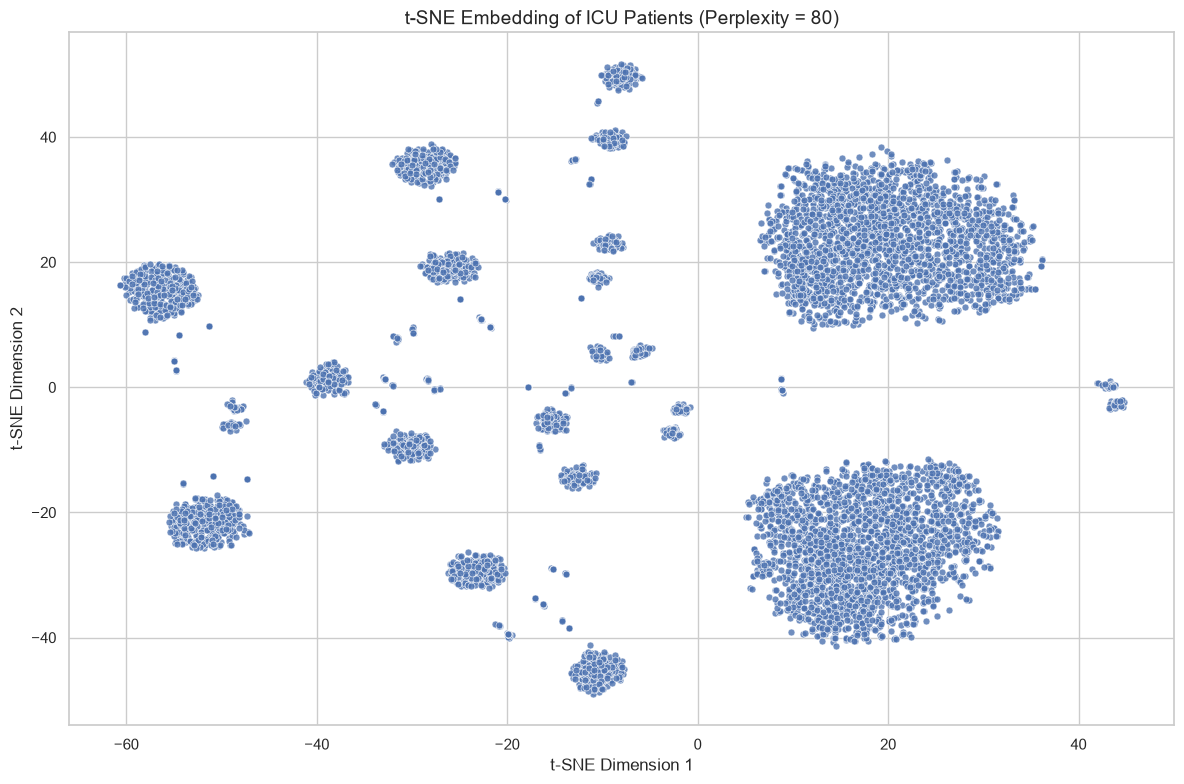

In [14]:
# Create the final 2D t-SNE scatter plot
plt.figure(figsize=(12, 8))

plt.scatter(
    tsne_df["tsne_1"],
    tsne_df["tsne_2"],
    s=25,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.8
)

# Add labels and title
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title(f"t-SNE Embedding of ICU Patients (Perplexity = {best_tsne_perplexity})")

# Adjust layout
plt.tight_layout()

# Save plot
plt.savefig(
    PLOTS_DIR / "02.tsne_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation :**

Creates a 2D scatter plot of the final t-SNE embedding using `tsne_1` and `tsne_2` for all `7,859` patients.

The plot shows several visibly separated patient groups, including large dense groups and multiple smaller groups.

The selected t-SNE embedding reveals strong local structure and possible subgroup patterns in the patient population. Visual separation alone does not determine the final number of clusters.

## UMAP Embedding

### Hyperparameter Search and Trustworthiness Evaluation

In [15]:
# Candidate UMAP hyperparameter values
n_neighbors_values = [5, 10, 20, 40, 50, 75, 100]
min_dist_values = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

# Store embeddings and results
umap_embeddings = {}
umap_tuning_results = []

# Test each hyperparameter combination
for n_neighbors in n_neighbors_values:
    for min_dist in min_dist_values:

        # Create UMAP model
        umap_model = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric="euclidean",
            random_state=RANDOM_SEED,
            n_jobs=1
        )

        # Apply UMAP directly to the feature matrix
        embedding = umap_model.fit_transform(X)

        # Store embedding
        umap_embeddings[(n_neighbors, min_dist)] = embedding

        # Calculate trustworthiness
        trust_score = trustworthiness(
            X,
            embedding,
            n_neighbors=30
        )

        # Calculate continuity by reversing the inputs
        continuity_score = trustworthiness(
            embedding,
            X,
            n_neighbors=30
        )

        # Calculate overall embedding quality
        quality_score = (
            trust_score + continuity_score
        ) / 2

        # Store results
        umap_tuning_results.append({
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "Trustworthiness": trust_score,
            "Continuity": continuity_score,
            "Quality_Score": quality_score
        })

        print(
            f"n_neighbors: {n_neighbors} | "
            f"min_dist: {min_dist} | "
            f"Trustworthiness: {trust_score:.4f} | "
            f"Continuity: {continuity_score:.4f} | "
            f"Quality: {quality_score:.4f}"
        )

# Convert results to DataFrame
umap_tuning_df = pd.DataFrame(umap_tuning_results)

# Sort from best to worst
umap_tuning_df = umap_tuning_df.sort_values(
    "Quality_Score",
    ascending=False
).reset_index(drop=True)

# Select best UMAP parameters
best_umap_neighbors = int(
    umap_tuning_df.loc[0, "n_neighbors"]
)

best_umap_min_dist = float(
    umap_tuning_df.loc[0, "min_dist"]
)

# Save results
umap_tuning_df.to_csv(
    RESULTS_DIR / "06.umap_embedding_quality.csv",
    index=False
)

print(f"\nBest UMAP n_neighbors: {best_umap_neighbors}")
print(f"Best UMAP min_dist: {best_umap_min_dist}")

display(umap_tuning_df)

n_neighbors: 5 | min_dist: 0.05 | Trustworthiness: 0.9578 | Continuity: 0.9682 | Quality: 0.9630
n_neighbors: 5 | min_dist: 0.1 | Trustworthiness: 0.9573 | Continuity: 0.9669 | Quality: 0.9621
n_neighbors: 5 | min_dist: 0.2 | Trustworthiness: 0.9556 | Continuity: 0.9672 | Quality: 0.9614
n_neighbors: 5 | min_dist: 0.3 | Trustworthiness: 0.9536 | Continuity: 0.9659 | Quality: 0.9598
n_neighbors: 5 | min_dist: 0.4 | Trustworthiness: 0.9516 | Continuity: 0.9674 | Quality: 0.9595
n_neighbors: 5 | min_dist: 0.5 | Trustworthiness: 0.9510 | Continuity: 0.9690 | Quality: 0.9600
n_neighbors: 10 | min_dist: 0.05 | Trustworthiness: 0.9573 | Continuity: 0.9713 | Quality: 0.9643
n_neighbors: 10 | min_dist: 0.1 | Trustworthiness: 0.9561 | Continuity: 0.9731 | Quality: 0.9646
n_neighbors: 10 | min_dist: 0.2 | Trustworthiness: 0.9538 | Continuity: 0.9724 | Quality: 0.9631
n_neighbors: 10 | min_dist: 0.3 | Trustworthiness: 0.9536 | Continuity: 0.9701 | Quality: 0.9618
n_neighbors: 10 | min_dist: 0.4 | 

,n_neighbors,min_dist,Trustworthiness,Continuity,Quality_Score
0,40,0.05,0.961579,0.979218,0.970399
1,50,0.05,0.960605,0.979433,0.970019
2,75,0.05,0.960392,0.979629,0.970011
3,40,0.10,0.960633,0.979145,0.969889
4,20,0.05,0.961763,0.977759,0.969761
5,50,0.10,0.959786,0.979734,0.969760
6,75,0.10,0.959959,0.979468,0.969713
7,40,0.20,0.959453,0.979889,0.969671
8,100,0.10,0.959466,0.979843,0.969655
9,75,0.20,0.959209,0.980084,0.969647


**Observation :**

Tests `42` UMAP configurations using different `n_neighbors` and `min_dist` values, then evaluates each embedding using `Trustworthiness`, `Continuity`, and `Quality Score`.

The best configuration is:
- `n_neighbors = 40`
- `min_dist = 0.05`
- Trustworthiness = `0.9616`
- Continuity = `0.9792`
- Quality Score = `0.9704`

Parameter meaning :
- `n_neighbors` : Controls how much UMAP focuses on local versus broader neighborhood structure.
- `min_dist` : Controls how tightly points are allowed to group together in the embedding.

This configuration gives the best overall balance between preserving original neighbors and maintaining neighborhood relationships in the 2D UMAP representation.

### KMeans Tuning on the Best UMAP Embedding

In [16]:
# Candidate numbers of clusters
k_values = range(3, 11)

# Get the best UMAP embedding
best_umap_embedding = umap_embeddings[
    (best_umap_neighbors, best_umap_min_dist)
]

# Store KMeans evaluation results
umap_kmeans_results = []

# Evaluate each value of k
for k in k_values:

    # Apply KMeans clustering
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_SEED
    )

    cluster_labels = kmeans.fit_predict(best_umap_embedding)

    # Calculate clustering metrics
    silhouette = silhouette_score(
        best_umap_embedding,
        cluster_labels,
        sample_size=2000,
        random_state=RANDOM_SEED
    )

    dbi = davies_bouldin_score(
        best_umap_embedding,
        cluster_labels
    )

    chi = calinski_harabasz_score(
        best_umap_embedding,
        cluster_labels
    )

    # Store results
    umap_kmeans_results.append({
        "k": k,
        "Silhouette": silhouette,
        "Davies_Bouldin": dbi,
        "Calinski_Harabasz": chi
    })

# Convert results to DataFrame
umap_kmeans_df = pd.DataFrame(umap_kmeans_results)

# Rank clustering metrics
umap_kmeans_df["Silhouette_Rank"] = (
    umap_kmeans_df["Silhouette"].rank(ascending=False)
)

umap_kmeans_df["DB_Rank"] = (
    umap_kmeans_df["Davies_Bouldin"].rank(ascending=True)
)

umap_kmeans_df["CH_Rank"] = (
    umap_kmeans_df["Calinski_Harabasz"].rank(ascending=False)
)

# Calculate total rank
umap_kmeans_df["Total_Rank"] = (
    umap_kmeans_df["Silhouette_Rank"]
    + umap_kmeans_df["DB_Rank"]
    + umap_kmeans_df["CH_Rank"]
)

# Sort from best to worst
umap_kmeans_df = umap_kmeans_df.sort_values(
    "Total_Rank"
).reset_index(drop=True)

# Select best k
best_umap_k = int(
    umap_kmeans_df.loc[0, "k"]
)

# Save results
umap_kmeans_df.to_csv(
    RESULTS_DIR / "07.umap_kmeans_evaluation.csv",
    index=False
)

print(f"Selected UMAP n_neighbors: {best_umap_neighbors}")
print(f"Selected UMAP min_dist: {best_umap_min_dist}")
print(f"Best Number of Clusters: {best_umap_k}")

display(umap_kmeans_df)

Selected UMAP n_neighbors: 40
Selected UMAP min_dist: 0.05
Best Number of Clusters: 10


,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Silhouette_Rank,DB_Rank,CH_Rank,Total_Rank
0,10,0.792057,0.454893,80026.659196,1.0,1.0,1.0,3.0
1,9,0.769254,0.544911,65098.943972,2.0,3.0,2.0,7.0
2,8,0.747705,0.559612,55336.452967,3.0,4.0,3.0,10.0
3,7,0.744440,0.654061,52132.837038,4.0,7.0,4.0,15.0
4,6,0.735499,0.652917,50038.141725,5.0,6.0,5.0,16.0
5,3,0.680056,0.487906,24979.764286,8.0,2.0,8.0,18.0
6,4,0.687670,0.634092,33932.408286,7.0,5.0,7.0,19.0
7,5,0.709902,0.683678,40004.464789,6.0,8.0,6.0,20.0


**Observation :**

Applies KMeas clustering to the selected UMAP embedding for `k = 3` to `k = 10` and evaluates each solution using Silhouette, Davies-Bouldin and Calinski-Harabasz scores.

`k = 10` is selected as the best solution with :
- Silhouette = `0.7921`
- Davies-Bouldin = `0.4549`
- Calinski-Harabasz = `80026.66`
- Total Rank = `3`

`k = 10` gives the strongest overall clustering quality in the UMAP space because it has the highest Silhouette, lowest Davies-Bouldin, and highest Calinski-Harabasz score.

### Final UMAP Hyperparameter Selection

In [17]:
# Select the best UMAP hyperparameters automatically
best_index = umap_tuning_df["Quality_Score"].idxmax()

best_umap_neighbors = int(
    umap_tuning_df.loc[best_index, "n_neighbors"]
)

best_umap_min_dist = float(
    umap_tuning_df.loc[best_index, "min_dist"]
)

print(f"Selected n_neighbors: {best_umap_neighbors}")
print(f"Selected min_dist: {best_umap_min_dist}")

Selected n_neighbors: 40
Selected min_dist: 0.05


**Observation :**

Selects the UMAP configuration with the highest `Quality Score` from the tuning results.

The selected parameters are :
- `n_neighbors = 40`
- `min_dist = 0.05`

This configuration achieved the best overall neighborhood preservation among the `42` tested UMAP settings.

Selecting parameters using the highest Quality Score provides an objective choice based on Trustworthiness and Continuity.

### Creating the Final UMAP Representation

In [18]:
# Create the final UMAP model using the selected hyperparameters
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=best_umap_neighbors,
    min_dist=best_umap_min_dist,
    metric="euclidean",
    random_state=RANDOM_SEED,
    n_jobs=1
)

# Create the final UMAP embedding
umap_embedding = umap_model.fit_transform(X)

# Store UMAP coordinates with patient IDs
umap_df = pd.DataFrame({
    "patientunitstayid": patient_ids,
    "umap_1": umap_embedding[:, 0],
    "umap_2": umap_embedding[:, 1]
})

# Save the final UMAP embedding
umap_df.to_csv(
    RESULTS_DIR / "08.umap_embedding.csv",
    index=False
)

# Display summary
print(f"Selected n_neighbors: {best_umap_neighbors}")
print(f"Selected min_dist: {best_umap_min_dist}")
print(f"Metric: euclidean")
print(f"UMAP Embedding Shape: {umap_embedding.shape}")

Selected n_neighbors: 40
Selected min_dist: 0.05
Metric: euclidean
UMAP Embedding Shape: (7859, 2)


**Observation :**

Creates the final 2D UMAP embedding using the selected hyperparameters `n_neighbors = 40` and `min_dist = 0.05` then stores the coordinates with patient IDs and saves them to a CSV file.

The final UMAP embedding has shape `(7859,2)` meaning all `7859` patients are represented using two UMAP dimensions.

Each patient is now represented by two non-linear UMAP coordinates that preserve neighbrhood structure based on the selected configuration.

The final UMAP model uses the best-performing hyperparameters identified during tuning providing the most reliable 2D UMAP representation for visualization and clustering.

## Plotting the UMAP Embedding

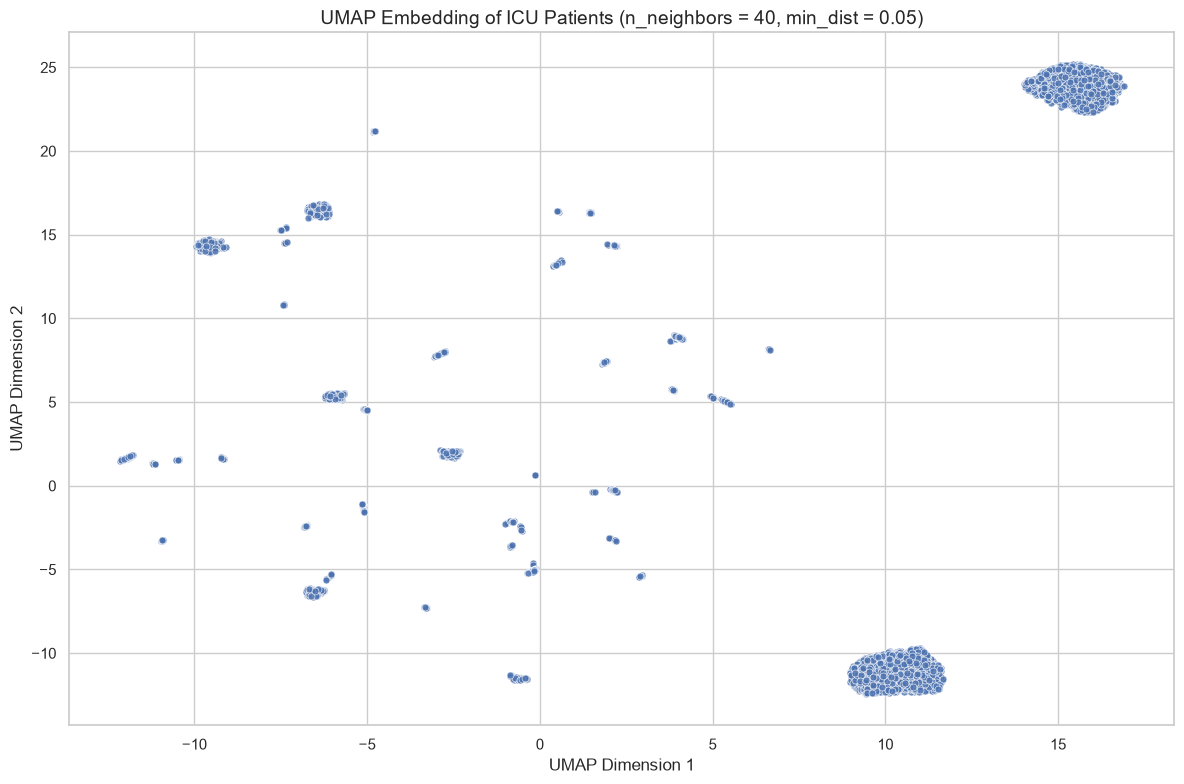

In [19]:
# Create the final 2D UMAP scatter plot
plt.figure(figsize=(12, 8))

plt.scatter(
    umap_df["umap_1"],
    umap_df["umap_2"],
    s=25,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.8
)

# Add labels and title
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title(
    f"UMAP Embedding of ICU Patients "
    f"(n_neighbors = {best_umap_neighbors}, "
    f"min_dist = {best_umap_min_dist})"
)

# Adjust layout
plt.tight_layout()

# Save plot
plt.savefig(
    PLOTS_DIR / "03.umap_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation :**

Plots the final 2D UMAP embedding using `umap_1` and `umap_2` for all patients.

The plot shows two large dense patient groups along with several smaller, clearly separated groups.

UMAP reveals strong nonlinear structure and distinct local patient subgroups in the dataset.

The 2D UMAP plot is used to visually inspect the neighborhood structure and possible cluster patterns before applying formal clustering.

## VAE Embedding

## Defining the VAE Architecture

In [20]:
# Select CPU or GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Define the Variational Autoencoder
class VAE(nn.Module):

    def __init__(self, input_dim, hidden_dim1, hidden_dim2, latent_dim=2):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU()
        )

        # Latent space
        self.mu_layer = nn.Linear(hidden_dim2, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim2, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim)
        )

    # Encode input
    def encode(self, x):
        encoded = self.encoder(x)

        mu = self.mu_layer(encoded)
        logvar = self.logvar_layer(encoded)

        return mu, logvar

    # Sample latent representation
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)

        return mu + epsilon * std

    # Decode latent representation
    def decode(self, z):
        return self.decoder(z)

    # Complete forward pass
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)

        return reconstructed, mu, logvar


print(f"Device Used: {device}")
print("VAE Architecture Defined Successfully")

Device Used: cuda
VAE Architecture Defined Successfully


**Observation :**

Defines a Variational Autoencoder with an encoder, a 2D probabilistic latent space (`mu` and `logvar`), a reparameterization step and a decoder that reconstructs the original `80` features.

`Device Used : cuda` means the VAE will use the GPU for faster training. VAE Architecture Defined Successfully confirms that the model structure was created without errors.

VAE is used to capture complex nonlinear relationships in the data and create a structured latent representation that can be compared with PCA, t-SNE, and UMAP.

### Preparing the Dataset for VAE Training

In [21]:
# Convert the feature matrix into a PyTorch tensor
X_tensor = torch.tensor(
    X.to_numpy(),
    dtype=torch.float32
)

# Create a dataset for VAE training
vae_dataset = TensorDataset(X_tensor)

# Display dataset information
print(f"VAE Dataset Shape: {X_tensor.shape}")
print(f"Number of Patients: {len(vae_dataset)}")
print(f"Number of Features: {X_tensor.shape[1]}")

VAE Dataset Shape: torch.Size([7859, 80])
Number of Patients: 7859
Number of Features: 80


**Observation :**

Converts the `7,859 × 80` feature matrix into a PyTorch `float32` tensor and wraps it in a `TensorDataset` for VAE training.

The VAE dataset contains `7,859` patients and `80` input features, matching the original clustering feature matrix.

The patient feature data has been successfully converted into the format required by PyTorch and is ready for VAE training.

PyTorch models require tensor-based input, while `TensorDataset` organizes the data so it can later be processed efficiently in training batches.

### Defining the VAE Loss Function

In [22]:
# Define the VAE loss function
def vae_loss(reconstructed, original, mu, logvar, beta):

    # Reconstruction loss
    reconstruction_loss = nn.functional.mse_loss(
        reconstructed,
        original,
        reduction="mean"
    )

    # KL-divergence loss
    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Total VAE loss
    total_loss = reconstruction_loss + beta * kl_loss

    return total_loss, reconstruction_loss, kl_loss


print("VAE Loss Function Defined Successfully")

VAE Loss Function Defined Successfully


**Observation :**

Defines the VAE loss as the sum of Reconstruction Loss and KL-Divergence Loss, controlled by the weighting parameter `beta`.

Metric meaning:
- `Reconstruction Loss`: Measures how accurately the VAE reconstructs the original 80 input features; lower is better.
- `KL-Divergence Loss`: Regularizes the latent space so it follows a smooth probability distribution.
- `Beta (β)`: Controls the importance of KL regularization relative to reconstruction accuracy.
- `Total Loss`: Reconstruction Loss + β × KL Loss.

The loss function balances accurate reconstruction of patient features with learning a structured and continuous latent space.

### Defining the VAE Training Function

In [23]:
# Define a reusable function for training one VAE model
def train_vae(
    hidden_dim1,
    hidden_dim2,
    learning_rate,
    beta,
    batch_size=128,
    epochs=50
):

    # Reset seeds for reproducible training
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

    # Create DataLoader
    train_loader = DataLoader(
        vae_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Create VAE model
    model = VAE(
        input_dim=X_tensor.shape[1],
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        latent_dim=2
    ).to(device)

    # Create optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # Store epoch losses
    epoch_losses = []

    # Train the VAE
    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for batch in train_loader:

            batch_data = batch[0].to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            reconstructed, mu, logvar = model(batch_data)

            # Calculate loss
            loss, _, _ = vae_loss(
                reconstructed,
                batch_data,
                mu,
                logvar,
                beta
            )

            # Update model
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Calculate average epoch loss
        average_loss = total_loss / len(train_loader)
        epoch_losses.append(average_loss)

    return model, epoch_losses


print("VAE Training Function Defined Successfully")

VAE Training Function Defined Successfully


**Observation :**

Defines a reusable function to train a VAE using selected hidden-layer sizes, learning rate, `beta`, batch size, and number of epochs.

The function can repeatedly train different VAE configurations while keeping the training process consistent and reproducible.

A reusable training function is required for systematic hyperparameter tuning so multiple VAE architectures can be compared under the same training procedure.

### Defining the VAE Latent Representation Function

In [24]:
# Define a function to extract the 2D VAE latent representation
def get_vae_embedding(model):

    # Switch model to evaluation mode
    model.eval()

    with torch.no_grad():

        # Move feature matrix to the selected device
        data = X_tensor.to(device)

        # Extract latent mean
        mu, _ = model.encode(data)

        # Convert embedding to NumPy
        embedding = mu.cpu().numpy()

    return embedding


print("VAE Latent Representation Function Defined Successfully")

VAE Latent Representation Function Defined Successfully


**Observation :**

Defines a function that passes all patient data through the trained VAE encoder and extracts the latent mean (`mu`) as the final 2D embedding.

Each patient will be represented by two latent coordinates learned by the VAE encoder.

The latent mean (`mu`) is used because it provides a stable and deterministic representation of each patient for visualization and clustering.

### Defining the VAE Hyperparameter Search Space

In [25]:
# Candidate encoder architectures
vae_hidden_configs = [
    (64, 32),
    (128, 64),
    (256, 128)
]

# Candidate learning rates
vae_learning_rates = [
    0.001,
    0.0007,
    0.0005
]

# Candidate beta values
vae_beta_values = [
    0.01,
    0.1,
    0.5,
    1.0
]

# Keep these settings fixed during the search
vae_batch_size = 128
vae_epochs = 100
vae_latent_dim = 2

# Calculate the total number of VAE configurations
total_vae_configs = (
    len(vae_hidden_configs)
    * len(vae_learning_rates)
    * len(vae_beta_values)
)

print(f"Hidden Layer Configurations : {vae_hidden_configs}")
print(f"Learning Rates : {vae_learning_rates}")
print(f"Beta Values : {vae_beta_values}")
print(f"Batch Size : {vae_batch_size}")
print(f"Epochs : {vae_epochs}")
print(f"Latent Dimensions : {vae_latent_dim}")
print(f"Total VAE Configurations : {total_vae_configs}")

Hidden Layer Configurations : [(64, 32), (128, 64), (256, 128)]
Learning Rates : [0.001, 0.0007, 0.0005]
Beta Values : [0.01, 0.1, 0.5, 1.0]
Batch Size : 128
Epochs : 100
Latent Dimensions : 2
Total VAE Configurations : 36


**Observation :**

Defines candidate hidden-layer architectures, learning rates, and `beta` values for VAE tuning while keeping batch size, epochs, and latent dimension fixed.

The search tests:
- Hidden layers: `(64,32), (128,64), (256,128)`
- Learning rates: `0.001, 0.0007, 0.0005`
- Beta values: `0.01, 0.1, 0.5, 1.0`
- Batch size: `128`
- Epochs: `100`
- Latent dimensions: `2`
- Total configurations: `36`

The VAE will be evaluated across `36` different combinations to identify the configuration that produces the best latent representation.

### VAE Hyperparameter Search and Trustworthiness Evaluation

In [26]:
# Store results and embeddings from every VAE configuration
vae_tuning_results = []
vae_embeddings = {}

configuration_number = 0

# Evaluate every VAE hyperparameter combination
for hidden_dim1, hidden_dim2 in vae_hidden_configs:

    for learning_rate in vae_learning_rates:

        for beta in vae_beta_values:

            configuration_number += 1

            print(
                f"Configuration {configuration_number}/{total_vae_configs} | "
                f"Hidden=({hidden_dim1}, {hidden_dim2}) | "
                f"LR={learning_rate} | Beta={beta}"
            )

            # Train the VAE
            model, epoch_losses = train_vae(
                hidden_dim1=hidden_dim1,
                hidden_dim2=hidden_dim2,
                learning_rate=learning_rate,
                beta=beta,
                batch_size=vae_batch_size,
                epochs=vae_epochs
            )

            # Extract the 2D latent embedding
            embedding = get_vae_embedding(model)

            # Store embedding
            vae_embeddings[
                (hidden_dim1, hidden_dim2, learning_rate, beta)
            ] = embedding

            # Calculate trustworthiness
            trust_score = trustworthiness(
                X,
                embedding,
                n_neighbors=30
            )

            # Calculate continuity
            continuity_score = trustworthiness(
                embedding,
                X,
                n_neighbors=30
            )

            # Calculate reconstruction error
            model.eval()

            with torch.no_grad():

                data = X_tensor.to(device)

                mu, _ = model.encode(data)
                reconstructed = model.decode(mu)

                reconstruction_mse = nn.functional.mse_loss(
                    reconstructed,
                    data,
                    reduction="mean"
                ).item()

            # Store results
            vae_tuning_results.append({
                "Hidden_Dim1": hidden_dim1,
                "Hidden_Dim2": hidden_dim2,
                "Learning_Rate": learning_rate,
                "Beta": beta,
                "Final_Training_Loss": epoch_losses[-1],
                "Trustworthiness": trust_score,
                "Continuity": continuity_score,
                "Reconstruction_MSE": reconstruction_mse
            })

# Convert results to DataFrame
vae_tuning_df = pd.DataFrame(vae_tuning_results)

# Save tuning results
vae_tuning_df.to_csv(
    RESULTS_DIR / "09.vae_tuning_results.csv",
    index=False
)

print("\nVAE Hyperparameter Search Completed")
print(f"Configurations Evaluated: {len(vae_tuning_df)}")

display(vae_tuning_df.head())

Configuration 1/36 | Hidden=(64, 32) | LR=0.001 | Beta=0.01
Configuration 2/36 | Hidden=(64, 32) | LR=0.001 | Beta=0.1
Configuration 3/36 | Hidden=(64, 32) | LR=0.001 | Beta=0.5
Configuration 4/36 | Hidden=(64, 32) | LR=0.001 | Beta=1.0
Configuration 5/36 | Hidden=(64, 32) | LR=0.0007 | Beta=0.01
Configuration 6/36 | Hidden=(64, 32) | LR=0.0007 | Beta=0.1
Configuration 7/36 | Hidden=(64, 32) | LR=0.0007 | Beta=0.5
Configuration 8/36 | Hidden=(64, 32) | LR=0.0007 | Beta=1.0
Configuration 9/36 | Hidden=(64, 32) | LR=0.0005 | Beta=0.01
Configuration 10/36 | Hidden=(64, 32) | LR=0.0005 | Beta=0.1
Configuration 11/36 | Hidden=(64, 32) | LR=0.0005 | Beta=0.5
Configuration 12/36 | Hidden=(64, 32) | LR=0.0005 | Beta=1.0
Configuration 13/36 | Hidden=(128, 64) | LR=0.001 | Beta=0.01
Configuration 14/36 | Hidden=(128, 64) | LR=0.001 | Beta=0.1
Configuration 15/36 | Hidden=(128, 64) | LR=0.001 | Beta=0.5
Configuration 16/36 | Hidden=(128, 64) | LR=0.001 | Beta=1.0
Configuration 17/36 | Hidden=(128

,Hidden_Dim1,Hidden_Dim2,Learning_Rate,Beta,Final_Training_Loss,Trustworthiness,Continuity,Reconstruction_MSE
0,64,32,0.0010,0.01,0.019345,0.904452,0.948679,0.015492
1,64,32,0.0010,0.10,0.019707,0.719687,0.861151,0.019705
2,64,32,0.0010,0.50,0.019708,0.674642,0.809197,0.019705
3,64,32,0.0010,1.00,0.019708,0.667342,0.812022,0.019705
4,64,32,0.0007,0.01,0.019287,0.875611,0.946181,0.015017


**Observation :**

Trains all `36` VAE configurations, extracts a 2D latent embedding from each model, and evaluates each using Trustworthiness, Continuity, Reconstruction MSE, and Final Training Loss.

All `36` configurations were evaluated successfully. From the displayed results, configurations with `Beta = 0.01` show better neighborhood preservation and lower reconstruction error than higher beta values.

Metric meaning:
- `Trustworthiness`: Measures how well original local neighbors are preserved in the 2D latent space; higher is better.
- `Continuity`: Measures how well original neighbors remain close after dimensionality reduction; higher is better.
- `Reconstruction MSE`: Measures how accurately the VAE reconstructs the original 80 features; lower is better.
- `Final Training Loss`: Final value of the VAE objective after training; lower generally indicates better optimization for that configuration.

Multiple VAE configurations are compared because architecture, learning rate, and `beta` directly affect latent-space quality and reconstruction performance.

### Select Best VAE Configuration

In [27]:
# Rank the VAE embedding quality metrics
vae_tuning_df["Trust_Rank"] = (
    vae_tuning_df["Trustworthiness"].rank(ascending=False)
)

vae_tuning_df["Continuity_Rank"] = (
    vae_tuning_df["Continuity"].rank(ascending=False)
)

vae_tuning_df["Reconstruction_Rank"] = (
    vae_tuning_df["Reconstruction_MSE"].rank(ascending=True)
)

# Calculate total rank
vae_tuning_df["Total_Rank"] = (
    vae_tuning_df["Trust_Rank"]
    + vae_tuning_df["Continuity_Rank"]
    + vae_tuning_df["Reconstruction_Rank"]
)

# Sort from best to worst
vae_tuning_df = vae_tuning_df.sort_values(
    "Total_Rank"
).reset_index(drop=True)

# Select best VAE hyperparameters
best_hidden_dim1 = int(vae_tuning_df.loc[0, "Hidden_Dim1"])
best_hidden_dim2 = int(vae_tuning_df.loc[0, "Hidden_Dim2"])
best_learning_rate = float(vae_tuning_df.loc[0, "Learning_Rate"])
best_beta = float(vae_tuning_df.loc[0, "Beta"])

# Get the selected VAE embedding
best_vae_embedding = vae_embeddings[
    (
        best_hidden_dim1,
        best_hidden_dim2,
        best_learning_rate,
        best_beta
    )
]

# Save ranked tuning results
vae_tuning_df.to_csv(
    RESULTS_DIR / "09.vae_tuning_results.csv",
    index=False
)

print(f"Selected Hidden Layers: ({best_hidden_dim1}, {best_hidden_dim2})")
print(f"Selected Learning Rate: {best_learning_rate}")
print(f"Selected Beta: {best_beta}")

display(vae_tuning_df)

Selected Hidden Layers: (256, 128)
Selected Learning Rate: 0.0005
Selected Beta: 0.01


,Hidden_Dim1,Hidden_Dim2,Learning_Rate,Beta,Final_Training_Loss,Trustworthiness,Continuity,Reconstruction_MSE,Trust_Rank,Continuity_Rank,Reconstruction_Rank,Total_Rank
0,256,128,0.0005,0.01,0.019322,0.920346,0.961824,0.012454,1.0,1.0,1.0,3.0
1,256,128,0.0010,0.01,0.019437,0.920281,0.958293,0.014414,2.0,3.0,5.0,10.0
2,64,32,0.0005,0.01,0.019270,0.909648,0.955335,0.014368,3.0,4.0,3.0,10.0
3,128,64,0.0010,0.01,0.019399,0.903743,0.959490,0.014401,5.0,2.0,4.0,11.0
4,64,32,0.0010,0.01,0.019345,0.904452,0.948679,0.015492,4.0,6.0,9.0,19.0
5,128,64,0.0005,0.01,0.019416,0.901684,0.948225,0.014508,6.0,7.0,6.0,19.0
6,256,128,0.0007,0.01,0.019439,0.868467,0.930502,0.014161,9.0,9.0,2.0,20.0
7,128,64,0.0007,0.01,0.019324,0.897788,0.950761,0.015465,7.0,5.0,8.0,20.0
8,64,32,0.0007,0.01,0.019287,0.875611,0.946181,0.015017,8.0,8.0,7.0,23.0
9,128,64,0.0007,0.10,0.019752,0.722723,0.887667,0.019697,13.0,12.0,13.0,38.0


**Observation :**

Ranks all `36` VAE configurations using Trustworthiness, Continuity, and Reconstruction MSE, then sums these ranks to select the overall best configuration.

The selected VAE configuration is:
- Hidden Layers: `(256, 128)`
- Learning Rate: `0.0005`
- Beta: `0.01`
- Trustworthiness: `0.9203`
- Continuity: `0.9618`
- Reconstruction MSE: `0.01245`
- Total Rank: `3`

This configuration gives the best combined balance between neighborhood preservation and reconstruction quality among all tested VAE settings.

### KMeans-Based VAE Embedding Evaluation

In [28]:
# Store KMeans results
vae_kmeans_results = []

# Evaluate k = 3 to 10
for k in range(3, 11):

    # Apply KMeans
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_SEED
    )

    cluster_labels = kmeans.fit_predict(best_vae_embedding)

    # Calculate clustering metrics
    silhouette = silhouette_score(
        best_vae_embedding,
        cluster_labels,
        sample_size=2000,
        random_state=RANDOM_SEED
    )

    dbi = davies_bouldin_score(
        best_vae_embedding,
        cluster_labels
    )

    chi = calinski_harabasz_score(
        best_vae_embedding,
        cluster_labels
    )

    # Store results
    vae_kmeans_results.append({
        "k": k,
        "Silhouette": silhouette,
        "Davies_Bouldin": dbi,
        "Calinski_Harabasz": chi
    })

# Convert to DataFrame
vae_kmeans_df = pd.DataFrame(vae_kmeans_results)

# Rank each metric
vae_kmeans_df["Silhouette_Rank"] = (
    vae_kmeans_df["Silhouette"].rank(ascending=False)
)

vae_kmeans_df["DB_Rank"] = (
    vae_kmeans_df["Davies_Bouldin"].rank(ascending=True)
)

vae_kmeans_df["CH_Rank"] = (
    vae_kmeans_df["Calinski_Harabasz"].rank(ascending=False)
)

# Calculate total rank
vae_kmeans_df["Total_Rank"] = (
    vae_kmeans_df["Silhouette_Rank"]
    + vae_kmeans_df["DB_Rank"]
    + vae_kmeans_df["CH_Rank"]
)

# Sort best to worst
vae_kmeans_df = vae_kmeans_df.sort_values(
    "Total_Rank"
).reset_index(drop=True)

# Select best k
best_vae_k = int(vae_kmeans_df.loc[0, "k"])

# Save results
vae_kmeans_df.to_csv(
    RESULTS_DIR / "10.vae_kmeans_evaluation.csv",
    index=False
)

print("VAE KMeans Evaluation Completed")
print(f"Best Number of Clusters: {best_vae_k}")

display(vae_kmeans_df)

VAE KMeans Evaluation Completed
Best Number of Clusters: 10


,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Silhouette_Rank,DB_Rank,CH_Rank,Total_Rank
0,10,0.877531,0.423434,49031.053216,1.0,2.0,1.0,4.0
1,9,0.851472,0.408944,39101.490200,2.0,1.0,2.0,5.0
2,8,0.818473,0.489211,28553.170056,3.0,3.0,3.0,9.0
3,7,0.804428,0.534142,22822.184167,4.0,4.0,4.0,12.0
4,6,0.779647,0.600814,19735.359567,5.0,6.0,5.0,16.0
5,4,0.662843,0.600679,12053.426701,7.0,5.0,7.0,19.0
6,5,0.745631,0.625063,14658.933758,6.0,7.0,6.0,19.0
7,3,0.588277,0.791506,10044.704170,8.0,8.0,8.0,24.0


**Observation :**

Applies KMeans to the best VAE Embedding for `k = 3` to `k = 10` and evaluates each solution using Silhouette, Davies-Bouldin and Calinski-Harabasz scores.

`k = 10` is selected with :
- Silhouette : `0.8775`
- Davies-Bouldin : `0.4234`
- Calinski-Harabasz : `49031.05`
- Total Rank = `4`

`k = 10` provides the best overall balance of compactness and separation in the VAE latent space among the tested cluster counts.

### Final VAE Hyperparameter Selection

In [29]:
# Select the best VAE configuration
best_vae = vae_tuning_df.iloc[0]

best_vae_hidden1 = int(best_vae["Hidden_Dim1"])
best_vae_hidden2 = int(best_vae["Hidden_Dim2"])
best_vae_learning_rate = float(best_vae["Learning_Rate"])
best_vae_beta = float(best_vae["Beta"])

print(f"Selected Hidden Layers: ({best_vae_hidden1}, {best_vae_hidden2})")
print(f"Selected Learning Rate: {best_vae_learning_rate}")
print(f"Selected Beta: {best_vae_beta}")
print(f"Total Rank: {best_vae['Total_Rank']:.0f}")

Selected Hidden Layers: (256, 128)
Selected Learning Rate: 0.0005
Selected Beta: 0.01
Total Rank: 3


**Observation :**

Extracts the top-ranked VAE configuration from the tuning results and stores its selected hidden-layer sizes, learning rate, and `beta`.

The selected configuration is:
- Hidden Layers: `(256, 128)`
- Learning Rate: `0.0005`
- Beta: `0.01`
- Total Rank: `3`

This configuration ranked best overall across Trustworthiness, Continuity, and Reconstruction MSE.

### Creating the Final VAE Representation

In [30]:
# Use the selected VAE embedding
vae_embedding = best_vae_embedding

# Create final VAE DataFrame
vae_df = pd.DataFrame({
    "patientunitstayid": patient_ids,
    "vae_1": vae_embedding[:, 0],
    "vae_2": vae_embedding[:, 1]
})

# Save final VAE embedding
vae_df.to_csv(
    RESULTS_DIR / "11.vae_embedding.csv",
    index=False
)

print(f"Selected Hidden Layers: ({best_vae_hidden1}, {best_vae_hidden2})")
print(f"Selected Learning Rate: {best_vae_learning_rate}")
print(f"Selected Beta: {best_vae_beta}")
print(f"VAE Embedding Shape: {vae_embedding.shape}")

Selected Hidden Layers: (256, 128)
Selected Learning Rate: 0.0005
Selected Beta: 0.01
VAE Embedding Shape: (7859, 2)


**Observation :**

Uses the best VAE embedding, stores the two latent dimensions as `vae_1` and `vae_2` with patient IDs, and saves the final embedding to a CSV file.

The selected model uses hidden layers `(256, 128)`, learning rate `0.0005`, and Beta = `0.01`. The final VAE embedding has shape `(7859, 2)`.

All `7,859` patients are represented by two learned nonlinear latent features produced by the best-performing VAE configuration.

## Plotting the VAE Embedding

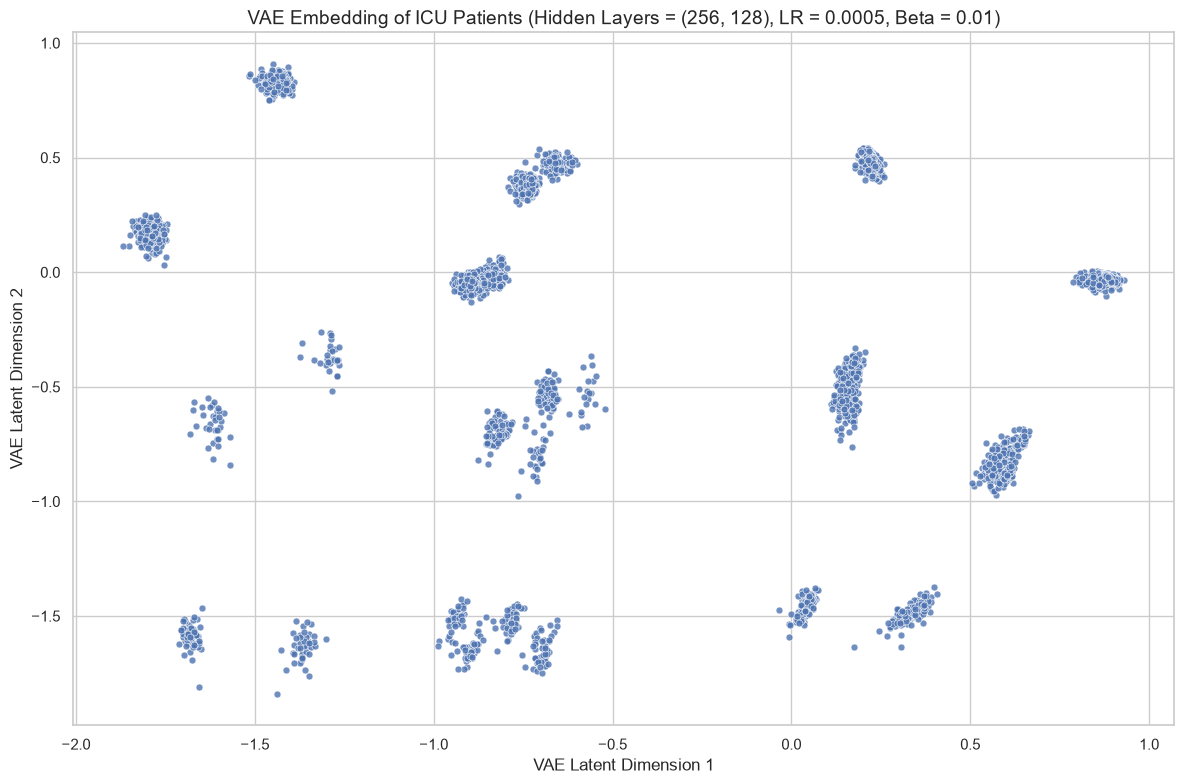

In [31]:
# Create the final 2D VAE scatter plot
plt.figure(figsize=(12, 8))

plt.scatter(
    vae_df["vae_1"],
    vae_df["vae_2"],
    s=25,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.8
)

# Add labels and title
plt.xlabel("VAE Latent Dimension 1")
plt.ylabel("VAE Latent Dimension 2")
plt.title(
    f"VAE Embedding of ICU Patients "
    f"(Hidden Layers = ({best_vae_hidden1}, {best_vae_hidden2}), "
    f"LR = {best_vae_learning_rate}, "
    f"Beta = {best_vae_beta})"
)

# Adjust layout
plt.tight_layout()

# Save plot
plt.savefig(
    PLOTS_DIR / "04.vae_embedding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation :**

Plots the final 2D VAE latent representation using `vae_1` and `vae_2` for all patients.

The scatter plot shows several clearly separated and compact patient groups in the learned VAE latent space.

The VAE has learned a nonlinear representation where distinct patient subgroup patterns are visible with relatively strong separation.

The 2D VAE plot is used to visually inspect the structure learned by the neural-network-based latent representation before applying formal clustering.

# KMeans Clustering

## Preparing the Embeddings for KMeans

In [32]:
# Prepare the four representations for KMeans clustering
clustering_embeddings = {
    "PCA": pca_embedding,
    # "t-SNE": tsne_embedding,
    # "UMAP": umap_embedding,
    # "VAE": vae_embedding
}

# Candidate numbers of clusters
k_values = list(range(3, 11))

# Display the dimensionality of each representation
for method, embedding in clustering_embeddings.items():
    print(
        f"{method:<6} : "
        f"{embedding.shape[0]} patients x "
        f"{embedding.shape[1]} dimensions"
    )

print(f"\nCandidate k Values : {k_values}")

PCA    : 7859 patients x 25 dimensions

Candidate k Values : [3, 4, 5, 6, 7, 8, 9, 10]


**Observation :**

Combines the final PCA, t-SNE, UMAP, and VAE representations into one dictionary and defines candidate cluster counts from `k = 3` to `k = 10`.
- PCA : `7859 x 25`
- t-SNE: `7,859 × 2`
- UMAP: `7,859 × 2`
- VAE: `7,859 × 2`
- Candidate `k: [3, 4, 5, 6, 7, 8, 9, 10]`

All four embeddings contain the same 7,859 patients but represent them in different-dimensional spaces. These representations will now be clustered separately for comparison.

## Running KMeans Across All Embeddings

In [33]:
# Store KMeans models, labels, and inertia
kmeans_models = {}
kmeans_labels = {}
kmeans_inertia = []

# Run KMeans for each embedding
for method, embedding in clustering_embeddings.items():

    print(f"\nRunning KMeans for {method}...")

    for k in k_values:

        # Create and fit KMeans
        kmeans = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=RANDOM_SEED
        )

        labels = kmeans.fit_predict(embedding)

        # Store model and labels
        kmeans_models[(method, k)] = kmeans
        kmeans_labels[(method, k)] = labels

        # Store inertia
        kmeans_inertia.append({
            "Method": method,
            "k": k,
            "Inertia": kmeans.inertia_
        })

        print(f"k = {k} completed")

# Convert to DataFrame
kmeans_inertia_df = pd.DataFrame(kmeans_inertia)

# Save results
kmeans_inertia_df.to_csv(
    RESULTS_DIR / "12.kmeans_inertia.csv",
    index=False
)

print("\nKMeans clustering completed for all embeddings.")
print(f"Total KMeans Solutions: {len(kmeans_labels)}")


Running KMeans for PCA...
k = 3 completed
k = 4 completed
k = 5 completed
k = 6 completed
k = 7 completed
k = 8 completed
k = 9 completed
k = 10 completed

KMeans clustering completed for all embeddings.
Total KMeans Solutions: 8


**Observation :**

Runs KMeans clustering on PCA, t-SNE, UMAP, and VAE embeddings for every `k` from `3 to 10`, and stores the models, cluster labels, and inertia values.

KMeans was successfully completed for all four embeddings and all eight candidate `k` values, producing `32` total clustering solutions.

`Inertia`: Sum of squared distances between each point and its assigned cluster centroid. Lower values indicate more compact clusters.

Each embedding now has comparable KMeans solutions for `k = 3 to 10`, allowing cluster quality and stability to be evaluated consistently across methods.

KMeans is applied uniformly across all embeddings so differences in clustering results can be compared under the same clustering algorithm and candidate cluster counts.

## Matching Cluster Labels Across Embeddings

In [34]:
# Store matched cluster labels
matched_kmeans_labels = {}

# Use PCA as the reference for each k
for k in k_values:

    # Keep PCA labels unchanged
    reference_labels = kmeans_labels[("PCA", k)]
    matched_kmeans_labels[("PCA", k)] = reference_labels.copy()

    # Match other methods to PCA
    for method in ["t-SNE", "UMAP", "VAE"]:

        current_labels = kmeans_labels[(method, k)]

        # Create cluster overlap table
        contingency_table = pd.crosstab(
            reference_labels,
            current_labels
        ).to_numpy()

        # Find the best label matching
        row_ind, col_ind = linear_sum_assignment(
            -contingency_table
        )

        # Create label mapping
        label_mapping = {
            current: reference
            for reference, current in zip(row_ind, col_ind)
        }

        # Apply label mapping
        matched_labels = np.array([
            label_mapping[label]
            for label in current_labels
        ])

        matched_kmeans_labels[(method, k)] = matched_labels


print("Cluster labels matched successfully.")
print(f"Total Matched Solutions: {len(matched_kmeans_labels)}")

KeyError: ('t-SNE', 3)

**Observation :**

Uses PCA cluster labels as the reference and matches t-SNE, UMAP, and VAE cluster labels to PCA using a contingency table and the Hungarian algorithm.

`32` matched clustering solutions were created successfully across `4` embeddings and `8` values of k.

The cluster numbering is now aligned across embeddings, so corresponding clusters can be compared consistently even if KMeans originally assigned different label numbers.

KMeans cluster numbers are arbitrary. Label matching ensures that cluster 0, 1, 2, etc. represent the closest corresponding groups across PCA, t-SNE, UMAP, and VAE.

## Visualizing KMeans Clustering Across Embeddings

In [ ]:
# Prepare 2D coordinates for visualization
plot_embeddings = {
    "PCA": pca_embedding[:, :2],
    "t-SNE": tsne_embedding,
    "UMAP": umap_embedding,
    "VAE": vae_embedding
}

methods = ["PCA", "t-SNE", "UMAP", "VAE"]

# Create 4 x 8 comparison figure
fig, axes = plt.subplots(
    nrows=4,
    ncols=8,
    figsize=(28, 14)
)

# Plot each embedding for k = 3 to 10
for row, method in enumerate(methods):

    coordinates = plot_embeddings[method]

    for col, k in enumerate(k_values):

        ax = axes[row, col]

        # Use matched labels for consistent colors
        labels = matched_kmeans_labels[(method, k)]

        # Discrete color map
        cmap = plt.get_cmap("tab10", k)

        ax.scatter(
            coordinates[:, 0],
            coordinates[:, 1],
            c=labels,
            cmap=cmap,
            s=8,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.2
        )

        # Column titles
        if row == 0:
            ax.set_title(
                f"k = {k}",
                fontsize=12,
                fontweight="bold"
            )

        # Row labels
        if col == 0:
            ax.set_ylabel(
                method,
                fontsize=12,
                fontweight="bold"
            )

        # Remove tick labels
        ax.set_xticks([])
        ax.set_yticks([])

# Overall title
fig.suptitle(
    "KMeans Clustering Across Dimensionality Reduction Methods",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

# Save figure
plt.savefig(
    PLOTS_DIR / "05.kmeans_embedding_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation :**

Creates a `4 × 8` comparison grid showing KMeans clustering for PCA, t-SNE, UMAP, and VAE across `k = 3 to 10`, using matched labels for consistent cluster colors.

- PCA: More overlap is visible in the first two principal components.
- t-SNE: Shows compact and separated groups.
- UMAP: Shows dense, clearly separated groups.
- VAE: Shows strong island-like cluster separation.

The nonlinear embeddings show clearer visual cluster separation than the 2D PCA view. However, visual separation alone should not determine the final value of `k`.

This visualization allows direct comparison of how cluster structure changes across embedding methods and different values of `k` before formal cluster validation.

# Cluster Validation

### Calculating Internal Validation Metrics

In [ ]:
# Store validation results
validation_results = []

# Evaluate each embedding for k = 3 to 10
for method, embedding in clustering_embeddings.items():

    print(f"Evaluating {method}...")

    for k in k_values:

        # Get KMeans labels and model
        labels = kmeans_labels[(method, k)]
        model = kmeans_models[(method, k)]

        # Calculate validation metrics
        silhouette = silhouette_score(
            embedding,
            labels,
            sample_size=2000,
            random_state=RANDOM_SEED
        )

        dbi = davies_bouldin_score(
            embedding,
            labels
        )

        chi = calinski_harabasz_score(
            embedding,
            labels
        )

        # Store results
        validation_results.append({
            "Method": method,
            "k": k,
            "Inertia": model.inertia_,
            "Silhouette": silhouette,
            "Davies_Bouldin": dbi,
            "Calinski_Harabasz": chi
        })

# Convert results to DataFrame
validation_df = pd.DataFrame(validation_results)

# Save results
validation_df.to_csv(
    RESULTS_DIR / "13.kmeans_validation_metrics.csv",
    index=False
)

print("\nCluster Validation Completed")
print(f"Total Solutions Evaluated: {len(validation_df)}")

display(validation_df)

**Observation :**

Evaluates all `32` KMeans solutions across PCA, t-SNE, UMAP, and VAE using Inertia, Silhouette, Davies-Bouldin, and Calinski-Harabasz metrics.

- PCA: Metrics disagree; cluster separation is weaker.
- t-SNE: `k = 8` gives the best overall balance.
- UMAP: `k = 10` performs best across all three major validation metrics.
- VAE: `k = 10` has the highest Silhouette and Calinski-Harabasz, while k = 9 has the lowest Davies-Bouldin score.

UMAP and VAE show much stronger internal clustering structure than PCA, while t-SNE shows moderate clustering quality.

## Evaluating KMeans and Selecting the Best `k` for Each Embedding

In [ ]:
# Copy the validation results
ranked_validation_df = validation_df.copy()

# Rank Silhouette: higher is better
ranked_validation_df["Silhouette_Rank"] = (
    ranked_validation_df
    .groupby("Method")["Silhouette"]
    .rank(ascending=False)
)

# Rank Davies-Bouldin: lower is better
ranked_validation_df["DB_Rank"] = (
    ranked_validation_df
    .groupby("Method")["Davies_Bouldin"]
    .rank(ascending=True)
)

# Rank Calinski-Harabasz: higher is better
ranked_validation_df["CH_Rank"] = (
    ranked_validation_df
    .groupby("Method")["Calinski_Harabasz"]
    .rank(ascending=False)
)

# Calculate total rank
ranked_validation_df["Total_Rank"] = (
    ranked_validation_df["Silhouette_Rank"]
    + ranked_validation_df["DB_Rank"]
    + ranked_validation_df["CH_Rank"]
)

# Sort results within each method
ranked_validation_df = ranked_validation_df.sort_values(
    ["Method", "Total_Rank"]
).reset_index(drop=True)

# Select the best k for each embedding
best_k_by_method = (
    ranked_validation_df
    .loc[
        ranked_validation_df
        .groupby("Method")["Total_Rank"]
        .idxmin()
    ]
    .reset_index(drop=True)
)

# Save results
ranked_validation_df.to_csv(
    RESULTS_DIR / "14.kmeans_ranked_validation.csv",
    index=False
)

best_k_by_method.to_csv(
    RESULTS_DIR / "15.best_k_by_embedding.csv",
    index=False
)

print("Best k for Each Embedding:")

display(
    best_k_by_method[
        [
            "Method",
            "k",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
            "Total_Rank"
        ]
    ]
)

**Observation :**

Ranks Silhouette, Davies-Bouldin, and Calinski-Harabasz scores within each embedding, sums the ranks, and selects the `k` with the lowest Total Rank for each method.

The selected best cluster counts are:
- PCA: `k = 7`, Total Rank = `10`
- t-SNE: `k = 8`, Total Rank = `5`
- UMAP: `k = 10`, Total Rank = `3`
- VAE: `k = 10`, Total Rank = `4`

Different embeddings favor different cluster structures. UMAP and VAE both strongly support `k = 10`, while t-SNE prefers `k = 8` and PCA prefers `k = 7`.

Rank aggregation combines three complementary clustering metrics, allowing the best `k` to be selected without relying on a single validation score.

## Evaluating Cluster Size Distribution

In [ ]:
# Store cluster size results
cluster_size_results = []

# Evaluate cluster sizes for every method and k
for method in clustering_embeddings.keys():

    for k in k_values:

        # Get cluster labels
        labels = kmeans_labels[(method, k)]

        # Count patients in each cluster
        cluster_counts = pd.Series(labels).value_counts().sort_index()

        for cluster, count in cluster_counts.items():

            cluster_size_results.append({
                "Method": method,
                "k": k,
                "Cluster": cluster,
                "Patient_Count": count,
                "Percentage": (count / len(labels)) * 100
            })

# Convert to DataFrame
cluster_size_df = pd.DataFrame(cluster_size_results)

# Save results
cluster_size_df.to_csv(
    RESULTS_DIR / "16.cluster_size_distribution.csv",
    index=False
)

print("Cluster Size Distribution Evaluated")

display(cluster_size_df)

**Observation :**

Calculates the number and percentage of patients in every cluster for each embedding method and every `k = 3 to 10`.

The output contains cluster-wise patient counts and percentages for all PCA, t-SNE, UMAP, and VAE clustering solutions.

The cluster-size distribution shows whether the clustering solutions are reasonably balanced or contain very small minority clusters.

Cluster size is checked to ensure that the selected clustering solution does not create extremely small clusters that may be unstable or difficult to interpret clinically.

## Summary of Cluster Sizes at Best `k`

In [ ]:
# Keep only the selected best k for each embedding
best_k_sizes = cluster_size_df.merge(
    best_k_by_method[["Method", "k"]],
    on=["Method", "k"],
    how="inner"
)

# Find the smallest cluster for each embedding
smallest_cluster_summary = (
    best_k_sizes
    .loc[
        best_k_sizes
        .groupby("Method")["Patient_Count"]
        .idxmin()
    ]
    .reset_index(drop=True)
)

# Rename columns for clarity
smallest_cluster_summary = smallest_cluster_summary.rename(
    columns={"k": "Best_k"}
)

# Round percentage
smallest_cluster_summary["Percentage"] = (
    smallest_cluster_summary["Percentage"].round(2)
)

# Keep required columns
smallest_cluster_summary = smallest_cluster_summary[
    [
        "Method",
        "Best_k",
        "Cluster",
        "Patient_Count",
        "Percentage"
    ]
]

print("Smallest Cluster at the Best k for Each Embedding:")

display(smallest_cluster_summary)

**Observation :**

Extracts the selected best `k` for each embedding and identifies the smallest cluster in each final clustering solution.
- PCA (`k = 7`): $521$ patients ($6.63\%$)
- t-SNE (`k = 8`): $393$ patients ($5.00\%$)
- UMAP (`k = 10`): $201$ patients ($2.56\%$)
- VAE (`k = 10`): $254$ patients ($3.23\%$)

UMAP produces the smallest minority cluster, while PCA produces the largest minimum cluster proportion. None of the selected solutions contains an extremely tiny cluster.

## Evaluating KMeans Stability Across Random Seeds

In [ ]:
# Random seeds for stability testing
stability_seeds = [
    RANDOM_SEED,
    42,
    123,
    456,
    789
]

# Store pairwise ARI results
stability_results = []

# Evaluate stability for each embedding and k
for method, embedding in clustering_embeddings.items():

    print(f"Evaluating stability for {method}...")

    for k in k_values:

        seed_labels = {}

        # Run KMeans with different seeds
        for seed in stability_seeds:

            kmeans = KMeans(
                n_clusters=k,
                init="k-means++",
                n_init=10,
                random_state=seed
            )

            seed_labels[seed] = kmeans.fit_predict(embedding)

        # Compare every pair of seed solutions
        for i in range(len(stability_seeds)):

            for j in range(i + 1, len(stability_seeds)):

                seed_1 = stability_seeds[i]
                seed_2 = stability_seeds[j]

                ari = adjusted_rand_score(
                    seed_labels[seed_1],
                    seed_labels[seed_2]
                )

                stability_results.append({
                    "Method": method,
                    "k": k,
                    "Seed_1": seed_1,
                    "Seed_2": seed_2,
                    "ARI": ari
                })

# Convert to DataFrame
stability_df = pd.DataFrame(stability_results)

# Save detailed results
stability_df.to_csv(
    RESULTS_DIR / "19.kmeans_stability_pairwise.csv",
    index=False
)

# Summarize stability
stability_summary = (
    stability_df
    .groupby(["Method", "k"])
    .agg(
        Mean_ARI=("ARI", "mean"),
        Std_ARI=("ARI", "std"),
        Min_ARI=("ARI", "min"),
        Max_ARI=("ARI", "max")
    )
    .reset_index()
)

# Save summary
stability_summary.to_csv(
    RESULTS_DIR / "20.kmeans_stability_summary.csv",
    index=False
)

print("\nKMeans Stability Evaluation Completed")
print(f"Pairwise Comparisons: {len(stability_df)}")

display(stability_summary)

**Observation :**

Runs KMeans multiple times using five different random seeds for each embedding and candidate `k`, then compares the resulting cluster assignments using Adjusted Rand Index (ARI).

At the selected best k values:
- PCA (`k = 7`): Mean ARI = $0.9508$
- t-SNE (`k = 8`): Mean ARI = $0.9274$
- UMAP (`k = 10`): Mean ARI = $1.0000$
- VAE (`k = 10`): Mean ARI = $0.9997$

ARI: Measures similarity between two clustering solutions; 1 means identical clustering, while values closer to 0 indicate weak agreement.

KMeans assignments are highly consistent across different initializations, especially for UMAP and VAE. This indicates strong clustering stability on the fixed embeddings.

KMeans depends on random centroid initialization, so testing multiple seeds verifies that the selected cluster structures are not caused by one particular random initialization.

## Evaluating Agreement Across Embeddings

In [ ]:
# Methods used for cross-embedding comparison
methods = ["PCA", "t-SNE", "UMAP", "VAE"]

# Store pairwise ARI values between embedding methods
embedding_agreement_results = []

# Compare every pair of embedding methods for each k
for k in k_values:

    for i in range(len(methods)):

        for j in range(i + 1, len(methods)):

            method_1 = methods[i]
            method_2 = methods[j]

            # Retrieve the original cluster labels
            labels_1 = kmeans_labels[(method_1, k)]
            labels_2 = kmeans_labels[(method_2, k)]

            # Calculate agreement using Adjusted Rand Index
            ari = adjusted_rand_score(
                labels_1,
                labels_2
            )

            embedding_agreement_results.append(
                {
                    "k": k,
                    "Method_1": method_1,
                    "Method_2": method_2,
                    "ARI": ari
                }
            )

# Convert results to DataFrame
embedding_agreement_df = pd.DataFrame(
    embedding_agreement_results
)

# Save detailed pairwise agreement results
embedding_agreement_df.to_csv(
    RESULTS_DIR / "21.embedding_pairwise_ari.csv",
    index=False
)

# Summarize agreement for each value of k
embedding_agreement_summary = (
    embedding_agreement_df
    .groupby("k")
    .agg(
        Mean_ARI=("ARI", "mean"),
        Std_ARI=("ARI", "std"),
        Min_ARI=("ARI", "min"),
        Max_ARI=("ARI", "max")
    )
    .reset_index()
)

# Save summarized agreement results
embedding_agreement_summary.to_csv(
    RESULTS_DIR / "22.embedding_agreement_summary.csv",
    index=False
)

print("Cross-Embedding Agreement Evaluation Completed")

display(embedding_agreement_df)

print("\nAgreement Summary by k:")
display(embedding_agreement_summary)

**Observation :**

Calculates pairwise Adjusted Rand Index (ARI) between PCA, t-SNE, UMAP, and VAE cluster assignments for each `k = 3 to 10`.

The strongest cross-embedding agreement occurs at `k = 8`:
- Mean ARI = $0.8826$
- Std ARI = $0.0292$
- Minimum ARI = $0.8470$
- Maximum ARI = $0.9236$

At $k = 8$, the four embedding methods produce the most similar and consistent patient groupings compared with the other tested values of $k$.

Cross-embedding ARI checks whether cluster structure is reproducible across different dimensionality-reduction methods rather than depending on only one embedding.

## Summarizing Evidence Across Candidate Values of `k`

In [ ]:
# Create cluster-size summary for each method and k
cluster_size_summary = (
    cluster_size_df
    .groupby(["Method", "k"])
    .agg(
        Smallest_Cluster_Percentage=("Percentage", "min")
    )
    .reset_index()
)


# ----------------------------------------
# 1. Internal validation evidence
# ----------------------------------------

validation_ranked = validation_df.copy()

# Rank metrics within each embedding
validation_ranked["Silhouette_Rank"] = (
    validation_ranked
    .groupby("Method")["Silhouette"]
    .rank(ascending=False)
)

validation_ranked["Davies_Bouldin_Rank"] = (
    validation_ranked
    .groupby("Method")["Davies_Bouldin"]
    .rank(ascending=True)
)

validation_ranked["Calinski_Harabasz_Rank"] = (
    validation_ranked
    .groupby("Method")["Calinski_Harabasz"]
    .rank(ascending=False)
)

# Average internal validation rank
validation_ranked["Internal_Validation_Rank"] = (
    validation_ranked[
        [
            "Silhouette_Rank",
            "Davies_Bouldin_Rank",
            "Calinski_Harabasz_Rank"
        ]
    ]
    .mean(axis=1)
)

# Summarize across embeddings
validation_k_summary = (
    validation_ranked
    .groupby("k")
    .agg(
        Mean_Internal_Validation_Rank=(
            "Internal_Validation_Rank",
            "mean"
        )
    )
    .reset_index()
)


# ----------------------------------------
# 2. Stability evidence
# ----------------------------------------

stability_k_summary = (
    stability_summary
    .groupby("k")
    .agg(
        Mean_Stability_ARI=("Mean_ARI", "mean")
    )
    .reset_index()
)


# ----------------------------------------
# 3. Cluster-size evidence
# ----------------------------------------

size_k_summary = (
    cluster_size_summary
    .groupby("k")
    .agg(
        Mean_Smallest_Cluster_Percentage=(
            "Smallest_Cluster_Percentage",
            "mean"
        ),
        Minimum_Cluster_Percentage=(
            "Smallest_Cluster_Percentage",
            "min"
        )
    )
    .reset_index()
)


# ----------------------------------------
# 4. Combine all evidence
# ----------------------------------------

k_evidence_summary = (
    validation_k_summary
    .merge(
        stability_k_summary,
        on="k"
    )
    .merge(
        embedding_agreement_summary[
            ["k", "Mean_ARI"]
        ],
        on="k"
    )
    .merge(
        size_k_summary,
        on="k"
    )
)

# Rename agreement column
k_evidence_summary = k_evidence_summary.rename(
    columns={
        "Mean_ARI": "Mean_Cross_Embedding_ARI"
    }
)


# ----------------------------------------
# 5. Rank each evidence category
# ----------------------------------------

# Lower internal validation rank is better
k_evidence_summary["Validation_Rank"] = (
    k_evidence_summary[
        "Mean_Internal_Validation_Rank"
    ]
    .rank(ascending=True)
)

# Higher stability is better
k_evidence_summary["Stability_Rank"] = (
    k_evidence_summary[
        "Mean_Stability_ARI"
    ]
    .rank(ascending=False)
)

# Higher agreement is better
k_evidence_summary["Agreement_Rank"] = (
    k_evidence_summary[
        "Mean_Cross_Embedding_ARI"
    ]
    .rank(ascending=False)
)

# Larger minimum cluster percentage is better
k_evidence_summary["Size_Rank"] = (
    k_evidence_summary[
        "Minimum_Cluster_Percentage"
    ]
    .rank(ascending=False)
)


# ----------------------------------------
# 6. Overall evidence rank
# ----------------------------------------

k_evidence_summary["Overall_Evidence_Rank"] = (
    k_evidence_summary[
        [
            "Validation_Rank",
            "Stability_Rank",
            "Agreement_Rank",
            "Size_Rank"
        ]
    ]
    .mean(axis=1)
)

# Sort best to worst
k_evidence_summary = k_evidence_summary.sort_values(
    "Overall_Evidence_Rank"
).reset_index(drop=True)


# Save results
k_evidence_summary.to_csv(
    RESULTS_DIR / "23.k_selection_evidence_summary.csv",
    index=False
)

print("Evidence Summary for Candidate k Values:")

display(k_evidence_summary)

**Observation :**  

Combines four criteria for every $k = 3 to 10$: internal validation, KMeans stability, cross-embedding agreement, and minimum cluster-size balance. Each criterion is ranked and averaged into an `Overall_Evidence_Rank`.

`k = 6` has the lowest Overall Evidence Rank of 3.75, making it the strongest combined candidate.

Interpretation:

- `k = 8` has the best cross-embedding agreement.
- `k = 10` has the best internal validation.
- `k = 6` provides the best overall balance across all four criteria.

The final k should not depend on one metric alone. Combining validation quality, stability, agreement, and cluster-size balance gives a more robust overall selection.

## Selecting the Final Number of Clusters

In [ ]:
# Select the strongest overall k
final_k_evidence = k_evidence_summary.iloc[[0]].copy()

# Extract final k
final_k = int(
    final_k_evidence["k"].iloc[0]
)

# Save final selection
final_k_evidence.to_csv(
    RESULTS_DIR / "24.final_k_selection.csv",
    index=False
)

# Display supporting evidence
print(f"Selected Final k: {final_k}")

print(
    f"Mean Internal Validation Rank: "
    f"{final_k_evidence['Mean_Internal_Validation_Rank'].iloc[0]:.4f}"
)

print(
    f"Mean Stability ARI: "
    f"{final_k_evidence['Mean_Stability_ARI'].iloc[0]:.4f}"
)

print(
    f"Mean Cross-Embedding ARI: "
    f"{final_k_evidence['Mean_Cross_Embedding_ARI'].iloc[0]:.4f}"
)

print(
    f"Minimum Cluster Percentage: "
    f"{final_k_evidence['Minimum_Cluster_Percentage'].iloc[0]:.2f}%"
)

print(
    f"Overall Evidence Rank: "
    f"{final_k_evidence['Overall_Evidence_Rank'].iloc[0]:.2f}"
)

**Observation :**  

Selects the candidate `k` with the lowest Overall Evidence Rank and stores it as the final cluster count.

The selected final value is `k = 6` with:
- Mean Internal Validation Rank = $4.9167$
- Mean Stability ARI = $0.9858$
- Mean Cross-Embedding ARI = $0.8469$
- Minimum Cluster Percentage = $5.37\%$
- Overall Evidence Rank = $3.75$

`k = 6` provides the best overall balance between clustering quality, stability, agreement across embeddings, and acceptable cluster sizes.

The final cluster count is selected using combined evidence rather than relying on a single metric or embedding method.

# Final Cluster Solution

## Saving Final Cluster Assignments

In [ ]:
# Create a DataFrame with the final cluster assignments
final_cluster_assignments = pd.DataFrame({
    "patientunitstayid": patient_ids,

    # Original KMeans labels
    "PCA_Cluster": kmeans_labels[("PCA", final_k)],
    "tSNE_Cluster": kmeans_labels[("t-SNE", final_k)],
    "UMAP_Cluster": kmeans_labels[("UMAP", final_k)],
    "VAE_Cluster": kmeans_labels[("VAE", final_k)],

    # Labels matched to PCA
    "PCA_Matched": matched_kmeans_labels[("PCA", final_k)],
    "tSNE_Matched": matched_kmeans_labels[("t-SNE", final_k)],
    "UMAP_Matched": matched_kmeans_labels[("UMAP", final_k)],
    "VAE_Matched": matched_kmeans_labels[("VAE", final_k)]
})

# Save final assignments
final_cluster_assignments.to_csv(
    RESULTS_DIR / f"25.final_cluster_assignments_k{final_k}.csv",
    index=False
)

print(f"Final k: {final_k}")
print(f"Number of Patients: {len(final_cluster_assignments)}")

display(final_cluster_assignments.head(20))

**Observation :**

Creates a final table for all `7,859` patients containing the original KMeans cluster labels and the PCA-matched labels from PCA, t-SNE, UMAP, and VAE for the selected `k = 6`.

The output confirms:
- Final `k = 6`
- Number of patients = `7,859`
- Each patient has cluster assignments from all four embedding methods.

Many patients receive the same matched cluster across multiple embeddings, while some patients differ because each embedding captures the data structure differently.

Saving both original and matched labels allows direct cross-method comparison and provides the required input for the consensus-clustering step.

## Creating Cross-Embedding Consensus Labels

In [ ]:
# Columns containing cluster labels matched to PCA
matched_columns = [
    "PCA_Matched",
    "tSNE_Matched",
    "UMAP_Matched",
    "VAE_Matched"
]

# Create consensus dataset
consensus_df = final_cluster_assignments[
    ["patientunitstayid"] + matched_columns
].copy()


# Determine consensus cluster for one patient
def get_consensus_label(row):

    # Count votes for each cluster
    vote_counts = row.value_counts()

    # Cluster with the most votes
    winning_cluster = vote_counts.idxmax()
    maximum_votes = vote_counts.max()

    # Require at least 3 out of 4 methods to agree
    if maximum_votes >= 3:
        return winning_cluster

    # Otherwise leave patient unassigned
    return np.nan


# Assign consensus cluster
consensus_df["Consensus_Cluster"] = (
    consensus_df[matched_columns]
    .apply(get_consensus_label, axis=1)
)

# Count votes supporting the consensus
consensus_df["Consensus_Votes"] = consensus_df.apply(
    lambda row: (
        sum(
            row[column] == row["Consensus_Cluster"]
            for column in matched_columns
        )
        if pd.notna(row["Consensus_Cluster"])
        else 0
    ),
    axis=1
)

# Calculate consensus confidence
consensus_df["Consensus_Confidence"] = (
    consensus_df["Consensus_Votes"] / 4
)

# Store cluster labels as nullable integers
consensus_df["Consensus_Cluster"] = (
    consensus_df["Consensus_Cluster"]
    .astype("Int64")
)

# Save consensus labels
consensus_df.to_csv(
    RESULTS_DIR / "26.cross_embedding_consensus_labels.csv",
    index=False
)

print(f"Number of Patients: {len(consensus_df)}")

print(
    f"Patients With Consensus Label: "
    f"{consensus_df['Consensus_Cluster'].notna().sum()}"
)

print(
    f"Patients Without Consensus Label: "
    f"{consensus_df['Consensus_Cluster'].isna().sum()}"
)

display(consensus_df.head())

**Observation :**

Combines the matched cluster labels from PCA, t-SNE, UMAP, and VAE and assigns a consensus cluster only when at least `3` out of `4` methods agree.
- Total patients: $7,859$
- Patients with consensus label: $6,994$
- Patients without consensus label: $865$
- `4/4` votes = $100\%$ confidence
- `3/4` votes = $75\%$ confidence

Most patients receive a consistent cluster assignment across multiple embeddings, while patients with insufficient agreement remain unassigned.

Consensus clustering reduces dependence on a single embedding method and keeps only cluster assignments supported by the majority of PCA, t-SNE, UMAP, and VAE.

## Checking for Consensus Ties and Agreement

In [ ]:
# Classify the agreement pattern for each patient
def get_agreement_pattern(row):

    vote_counts = row[matched_columns].value_counts()

    # Sort vote counts from highest to lowest
    vote_pattern = sorted(
        vote_counts.tolist(),
        reverse=True
    )

    if vote_pattern == [4]:
        return "4-0 Agreement"

    elif vote_pattern == [3, 1]:
        return "3-1 Agreement"

    elif vote_pattern == [2, 1, 1]:
        return "2-1-1 Agreement"

    elif vote_pattern == [2, 2]:
        return "2-2 Tie"

    elif vote_pattern == [1, 1, 1, 1]:
        return "1-1-1-1 Tie"

    return "Other"


# Apply agreement classification
consensus_df["Agreement_Pattern"] = (
    consensus_df[matched_columns]
    .apply(
        get_agreement_pattern,
        axis=1
    )
)

# Identify patients without accepted consensus
consensus_df["No_Consensus"] = (
    consensus_df["Consensus_Cluster"].isna()
)

# Identify actual ties
consensus_df["Has_Tie"] = (
    consensus_df["Agreement_Pattern"]
    .isin([
        "2-2 Tie",
        "1-1-1-1 Tie"
    ])
)


# Summarize agreement patterns
agreement_summary = (
    consensus_df["Agreement_Pattern"]
    .value_counts()
    .rename_axis("Agreement_Pattern")
    .reset_index(name="Patient_Count")
)

# Calculate percentage
agreement_summary["Percentage"] = (
    agreement_summary["Patient_Count"]
    / len(consensus_df)
    * 100
)

# Extract patients with actual ties
consensus_ties_df = consensus_df[
    consensus_df["Has_Tie"]
].copy()

# Save agreement summary
agreement_summary.to_csv(
    RESULTS_DIR / "27.consensus_agreement_summary.csv",
    index=False
)

# Save tied patients
consensus_ties_df.to_csv(
    RESULTS_DIR / "28.consensus_tied_patients.csv",
    index=False
)

print("Consensus Agreement Summary:")
display(agreement_summary)

print(
    f"\nPatients Without Consensus: "
    f"{consensus_df['No_Consensus'].sum()}"
)

print(
    f"Patients With Actual Ties: "
    f"{len(consensus_ties_df)}"
)

print(
    f"Tie Percentage: "
    f"{len(consensus_ties_df) / len(consensus_df) * 100:.2f}%"
)

**Observation :**

Classifies each patient based on how the four embedding methods agree: `4-0`, `3-1`, `2-2`, or `2-1-1`, and identifies patients without consensus or with actual ties.
- `4-0` Agreement: $5,756$ patients ($73.24\%$)
- `3-1` Agreement: $1,238$ patients ($15.75\%$)
- `2-2` Tie: $508$ patients ($6.46\%$)
- `2-1-1` Agreement: $357$ patients ($4.54\%$)
- Patients without consensus: $865$
- Patients with actual ties: $508$

$88.99\%$ of patients have strong agreement from at least $3$ of the $4$ embedding methods, while only $6.46\%$ have a true `2-2` tie.

This step distinguishes strong consensus from ambiguous assignments and identifies patients whose cluster membership is not reliably supported across embedding methods.

## Creating the High-Confidence Consensus Dataset

In [ ]:
# Keep patients with at least 3 out of 4 methods agreeing
high_confidence_consensus_df = consensus_df[
    consensus_df["Consensus_Confidence"] >= 0.75
].copy()

# Convert consensus cluster to integer
high_confidence_consensus_df["Consensus_Cluster"] = (
    high_confidence_consensus_df["Consensus_Cluster"]
    .astype(int)
)

# Calculate cluster distribution
high_confidence_cluster_summary = (
    high_confidence_consensus_df["Consensus_Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Consensus_Cluster")
    .reset_index(name="Patient_Count")
)

# Calculate percentages
high_confidence_cluster_summary["Percentage"] = (
    high_confidence_cluster_summary["Patient_Count"]
    / len(high_confidence_consensus_df)
    * 100
)

# Save high-confidence dataset
high_confidence_consensus_df.to_csv(
    RESULTS_DIR / "29.high_confidence_consensus_dataset.csv",
    index=False
)

# Save cluster-size summary
high_confidence_cluster_summary.to_csv(
    RESULTS_DIR / "30.high_confidence_consensus_cluster_sizes.csv",
    index=False
)

print(f"Total Patients: {len(consensus_df)}")

print(
    f"High-Confidence Consensus Patients: "
    f"{len(high_confidence_consensus_df)}"
)

print(
    f"High-Confidence Percentage: "
    f"{len(high_confidence_consensus_df) / len(consensus_df) * 100:.2f}%"
)

print(
    f"Patients Excluded From High-Confidence Dataset: "
    f"{len(consensus_df) - len(high_confidence_consensus_df)}"
)

print("\nHigh-Confidence Consensus Cluster Distribution:")

display(high_confidence_cluster_summary)

**Observation :**

Keeps only patients with consensus confidence of at least `0.75`, meaning at least `3` out of `4` embedding methods agree, and calculates the final cluster distribution.

- Total patients: $7,859$
- High-confidence patients: $6,994$
- High-confidence percentage: $88.99\%$
- Excluded patients: $865$

Final Cluster Distribution :
- Cluster 0 : $2,118$ ($30.28\%$)
- Cluster 1: $2,195$ ($31.38\%$)
- Cluster 2: $778$ ($11.12\%$)
- Cluster 3: $552$ ($7.89\%$)
- Cluster 4: $523$ ($7.48\%$)
- Cluster 5: $828$ ($11.84\%$)

Most patients have reliable consensus assignments, and all six clusters contain meaningful numbers of patients without any extremely small cluster.

Using only high-confidence patients reduces uncertainty and provides a more reliable dataset for later patient profiling and clinical interpretation.

## Comparing Final Solutions Across Embeddings

In [ ]:
# Create cluster-size summary for each method and k
cluster_size_summary = (
    cluster_size_df
    .groupby(["Method", "k"])
    .agg(
        Smallest_Cluster_Count=("Patient_Count", "min"),
        Largest_Cluster_Count=("Patient_Count", "max"),
        Smallest_Cluster_Percentage=("Percentage", "min"),
        Largest_Cluster_Percentage=("Percentage", "max")
    )
    .reset_index()
)


# Extract validation results for the final k
final_method_comparison = validation_df[
    validation_df["k"] == final_k
][
    [
        "Method",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
].copy()


# Add KMeans stability
final_method_comparison = final_method_comparison.merge(
    stability_summary[
        stability_summary["k"] == final_k
    ][
        [
            "Method",
            "Mean_ARI",
            "Min_ARI"
        ]
    ],
    on="Method"
)

# Rename stability columns
final_method_comparison = final_method_comparison.rename(
    columns={
        "Mean_ARI": "Mean_Stability_ARI",
        "Min_ARI": "Minimum_Stability_ARI"
    }
)


# Add cluster-size information
final_method_comparison = final_method_comparison.merge(
    cluster_size_summary[
        cluster_size_summary["k"] == final_k
    ][
        [
            "Method",
            "Smallest_Cluster_Count",
            "Largest_Cluster_Count",
            "Smallest_Cluster_Percentage",
            "Largest_Cluster_Percentage"
        ]
    ],
    on="Method"
)


# Calculate agreement of each method with the other methods
agreement_rows = []

final_agreement = embedding_agreement_df[
    embedding_agreement_df["k"] == final_k
]

for method in methods:

    method_agreement = final_agreement[
        (final_agreement["Method_1"] == method)
        |
        (final_agreement["Method_2"] == method)
    ]

    agreement_rows.append({
        "Method": method,
        "Mean_Agreement_With_Other_Methods":
            method_agreement["ARI"].mean()
    })

agreement_by_method = pd.DataFrame(agreement_rows)


# Add cross-embedding agreement
final_method_comparison = final_method_comparison.merge(
    agreement_by_method,
    on="Method"
)


# Save final method comparison
final_method_comparison.to_csv(
    RESULTS_DIR / f"31.final_k{final_k}_method_comparison.csv",
    index=False
)

print(
    f"Comparison of Final k = {final_k} Solutions Across Embeddings:"
)

display(final_method_comparison)

**Observation :**

Compares PCA, t-SNE, UMAP, and VAE at the final $k = 6$ using internal validation metrics, KMeans stability, cluster-size balance, and agreement with the other embedding methods.
- PCA: Silhouette = $0.2541$, DBI = $1.6350$, Mean Stability ARI = $0.9431$
- t-SNE: Silhouette = $0.5685$, DBI = $0.6979$, Mean Stability ARI = $1.0000$
- UMAP: Silhouette = $0.7355$, CH = $50038.14$, Mean Stability ARI = $1.0000$
- VAE: Silhouette = $0.7796$, DBI = $0.6008$, Mean Stability ARI = $1.0000$

VAE shows the strongest compactness and separation, while UMAP shows the strongest Calinski-Harabasz score and better minimum cluster balance. PCA has weaker internal clustering quality but the highest mean agreement with the other methods ($0.8675$).

Comparing all embeddings at the same final $k = 6$ shows how consistently the selected cluster structure is supported across different dimensionality-reduction methods.

## Comparing Consensus Labels With Individual Embedding Methods

In [ ]:
# Use high-confidence consensus patients
consensus_comparison_df = high_confidence_consensus_df.copy()

# Store comparison results
consensus_method_results = []

# Compare consensus with each embedding method
for method_column, method_name in [
    ("PCA_Matched", "PCA"),
    ("tSNE_Matched", "t-SNE"),
    ("UMAP_Matched", "UMAP"),
    ("VAE_Matched", "VAE")
]:

    # Adjusted Rand Index
    ari = adjusted_rand_score(
        consensus_comparison_df["Consensus_Cluster"],
        consensus_comparison_df[method_column]
    )

    # Exact patient-level agreement
    exact_agreement = (
        consensus_comparison_df["Consensus_Cluster"]
        == consensus_comparison_df[method_column]
    ).mean() * 100

    # Store results
    consensus_method_results.append({
        "Method": method_name,
        "Consensus_ARI": ari,
        "Exact_Agreement_Percentage": exact_agreement
    })

# Convert to DataFrame
consensus_method_comparison = pd.DataFrame(
    consensus_method_results
)

# Sort by ARI
consensus_method_comparison = (
    consensus_method_comparison
    .sort_values(
        "Consensus_ARI",
        ascending=False
    )
    .reset_index(drop=True)
)

# Save results
consensus_method_comparison.to_csv(
    RESULTS_DIR / "32.consensus_method_comparison.csv",
    index=False
)

print(
    f"High-Confidence Consensus Patients: "
    f"{len(consensus_comparison_df)}"
)

print("\nConsensus Agreement With Individual Embedding Methods:")

display(consensus_method_comparison)

**Observation :**

Compares the high-confidence consensus labels with PCA, t-SNE, UMAP, and VAE cluster assignments using Adjusted Rand Index (ARI) and Exact Agreement Percentage.

- PCA: ARI = $0.9977$, Exact Agreement = $99.79\%$
- UMAP: ARI = $0.9568$, Exact Agreement = $95.34\%$
- VAE: ARI = $0.9547$, Exact Agreement = $91.41\%$
- t-SNE: ARI = $0.9381$, Exact Agreement = $95.77\%$

The consensus labels are highly consistent with all four embedding methods, with the strongest agreement observed with PCA.

ARI measures similarity in overall cluster structure, while Exact Agreement measures patient-level label matching; using both provides a more complete comparison of the consensus solution.

## Final KMeans Clustering Visualization Across Embeddings (`k = 6`)

In [ ]:
# Final KMeans clustering visualization for k = 6
final_k = 6

# 2D coordinates for plotting
plot_embeddings = {
    "PCA": pca_embedding[:, :2],
    "t-SNE": tsne_embedding,
    "UMAP": umap_embedding,
    "VAE": vae_embedding
}

# Axis labels
axis_labels = {
    "PCA": ("PC1", "PC2"),
    "t-SNE": ("t-SNE 1", "t-SNE 2"),
    "UMAP": ("UMAP 1", "UMAP 2"),
    "VAE": ("VAE 1", "VAE 2")
}

# Same colors for the 6 clusters across all embeddings
palette = sns.color_palette("tab10", final_k)

# Plot each embedding separately
for method, coordinates in plot_embeddings.items():

    labels = matched_kmeans_labels[(method, final_k)]

    plt.figure(figsize=(12, 8))

    sns.scatterplot(
        x=coordinates[:, 0],
        y=coordinates[:, 1],
        hue=labels,
        palette=palette,
        s=35,
        alpha=0.8,
        edgecolor="white",
        linewidth=0.2
    )

    plt.title(
        f"{method} Embedding with KMeans Clustering (k = 6)",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(axis_labels[method][0], fontsize=12)
    plt.ylabel(axis_labels[method][1], fontsize=12)

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    # Save each figure separately
    plt.savefig(
        PLOTS_DIR / f"06.{method.lower().replace('-', '').replace(' ', '_')}_kmeans_k6.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()